# 🎓 Tech Challenge - Fase 1: Análise de NPS para E-Commerce
## Pós-Graduação AI Scientist | FIAP
### Metodologia: CRISP-DM

---

> **Como usar este notebook:**
> Este material foi construído para ser lido **sequencialmente**.
> Cada célula de código tem comentários explicando:
> - 🤔 **POR QUÊ** fazemos isso (lógica de negócio/científica)
> - ⚙️ **COMO** funciona (explicação técnica)
> - 📊 **O QUE** o resultado nos diz (interpretação)

| Item | Detalhe |
|------|----------|
| **Dataset** | `desafio_nps_fase_1.csv` — 2.500 pedidos de e-commerce |
| **Problema** | NPS médio crítico (4.38/10) — empresa com alta taxa de detratores |
| **Objetivo** | Identificar causas e prever clientes detratores antes do churn |
| **Metodologia** | CRISP-DM (6 fases) |
| **Linguagem** | Python 3 + scikit-learn + pandas + seaborn |

---

---
## ⚙️ Bloco 0: Configuração e Importação de Bibliotecas
> **Por quê:** Python não vem com tudo pronto. Importamos ferramentas especializadas desenvolvidas pela comunidade científica.

In [1]:
# ---- Manipulacao de Dados ----
import pandas as pd       # A biblioteca central do Data Science em Python
import numpy as np        # Matematica vetorial de alta performance

# ---- Visualizacao ----
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- Machine Learning (scikit-learn) ----
from sklearn.pipeline       import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing  import StandardScaler, LabelEncoder
from sklearn.linear_model   import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree           import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble       import (RandomForestClassifier, RandomForestRegressor,
                                     GradientBoostingClassifier)
from sklearn.metrics        import (mean_absolute_error, mean_squared_error, r2_score,
                                     classification_report, confusion_matrix,
                                     f1_score, accuracy_score,
                                     precision_score, recall_score,
                                     precision_recall_curve)

# ---- Estatistica Inferencial ----
from scipy import stats

# ---- Estilo dos graficos ----
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_palette("deep")
sns.set_style("whitegrid")

print("✅ Todas as bibliotecas importadas com sucesso!")
print(f"   pandas  v{pd.__version__}")
print(f"   numpy   v{np.__version__}")

✅ Todas as bibliotecas importadas com sucesso!
   pandas  v2.2.2
   numpy   v2.0.2


---
## 📋 Bloco 1 (CRISP-DM): Business Understanding
### "Nunca comece pelo código. Comece pela pergunta."

O CRISP-DM estipula que **toda análise começa pelo entendimento do negócio**.
Antes de uma linha de código, precisamos documentar:

| Elemento | Descrição |
|----------|-----------|
| **Dor de Negócio** | "Nossa nota NPS está caindo e não sabemos o porquê" |
| **Tradução Analítica** | Quais variáveis operacionais causam a queda? Qual a probabilidade de um pedido gerar Detrator? |
| **Meta de Negócio** | Reduzir detratores em 15% em 6 meses |
| **Meta Analítica** | F1-Score(macro) ≥ 0.50 \| suporte estatístico p < 0.05 |

### ⚠️ Armadilhas que vamos evitar (aprendidas nas aulas):
1. **Data Leakage** — usar variáveis do futuro para prever o passado
2. **Acurácia em dados desbalanceados** — ilusão de boa performance
3. **Complexidade desnecessária** — *"Simple is better than complex"* (PEP 20)

* **Qual problema de negócio?**
Uma crise crônica de satisfação, refletida em um NPS médio de 4.38. O foco não é "medir o número", mas encontrar quais falhas na operação estão transformando clientes em detratores antes do encerramento da jornada, permitindo ações compensatórias antecipadas.

* **Por que o NPS é tão importante para o e-commerce?**
Diferente das finanças, o NPS é um *leading indicator* (indicador antecedente). Ele reflete sentimentos e expectativas de rentabilidade futura.
   * **Recompra:** Promotores costumam ter o Lifetime Value (LTV) elevado, sendo a base que rentabiliza o e-commerce no médio-longo prazo. Detratores exigem alto Custo de Aquisição (CAC) constante para serem substituídos.
   * **Boca a boca e Market Share:** Em um mercado de produtos muitas vezes iguais (e-commerce), a qualidade da experiência define quem ganha mercado. Um detrator afeta ativamente a base orgânica opinando mal em redes (ReclameAqui), enquanto um promotor realiza *Marketing Gratuito* impulsionando o *Market Share*.

* **Quais áreas poderiam se beneficiar com nosso modelo?**
   * **Logística e Supply Chain:** Para prever falhas de SLA e recalcular rotas tempestivamente.
   * **Atendimento (CS):** Redirecionar clientes em rotas "prestes a se tornarem detratores" para filas prioritárias VIP.
   * **Marketing & CRM:** Poupar dinheiro evitando disparos de campanhas genéricas e executando ações cirúrgicas (retenção customizada e Cupons).

* **Indicadores Complementares:**
Para somar ao NPS, deveríamos avaliar o **SLA Logístico interno (OTIF - On Time In Full)**, monitorar os **Benchmarks da Concorrência** para a mesma Região Física, e talvez cruzar com um **CES (Customer Effort Score)**, indicando o desgaste nos "x contatos de suporte" citados nos nossos dados.


---
## 🔍 Bloco 2 (CRISP-DM): Data Understanding
### Primeiro: conheça seus dados antes de tocar neles

> **Por quê:** Dados sujos = modelos ruins. *"Garbage in, garbage out."*
> Precisamos saber o que temos, o que está faltando e o que pode nos enganar.

* **Qual variável representa a satisfação?**
A nossa variável alvo primária é a transformação do score contínuo (`nps_score`) para o formato categórico baseado em classes de mercado: **Detratores, Neutros e Promotores (`nps_class`)**.  

* **Por que ela foi escolhida (Problema de Classificação)?**
Prever se uma nota seria "4.2" ou "4.8" tem valor de decisão nulo para o negócio, pois o plano de ação seria idêntico (reter). Agrupá-los em classes (Foco em Classificação) nos diz exatamente qual engrenagem apertar: precisamos detectar perfis *Detratores*.

* **Em que momento da jornada a Target é coletada?**
Ela compõe a experiência pós-venda (*Lagging Indicator*). Ela surge no fim, englobando a sensação residual após o processo de descobrimento, pagamento, entrega e de eventuais atritos resolvidos (ou não resolvidos) pelo CS.

* **Fatores de Risco no Uso da Target:**
   1. **Data Leakage ("Prever o passado"):** Usar atributos como `repeat_purchase_30d` (Recompra) e CSAT interno misturados nos dados geram alucinação positiva, pois as mesmas ocorrem paralelamente ou após a pesquisa (fator abordado empíricamente ao longo dos testes).
   2. **Matriz de Confusão "Míope" (Overfitting em Neutro/Promotor):** Observar a acurácia é um grande risco na variável NPS dado o gritante desbalanceamento de classes (84.4%). O erro fatal aqui é acertar todos os promotores (simplicidade técnica) mas falhar em salvar a base orgânica que se esvai com um Churn alto de Detratores.


In [2]:
# 2.1 CARREGAMENTO DOS DADOS
# Por que: pd.read_csv() le o arquivo e cria um DataFrame
#          (tabela estruturada) na memoria do Python.
#
# Como: Usar path relativo simples para garantir
#           reprodutibilidade em qualquer maquina.
#           Coloque o CSV na mesma pasta deste notebook.


DATA_PATH = 'desafio_nps_fase_1.csv'   # ← path relativo: funciona em qualquer máquina
df = pd.read_csv(DATA_PATH)

print(f"📐 Dimensoes do Dataset: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print()
print("📋 Primeiras 5 linhas do dataset:")
df.head()

📐 Dimensoes do Dataset: 2,500 linhas x 19 colunas

📋 Primeiras 5 linhas do dataset:


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
# 2.2 QUALIDADE DOS DADOS
# Por que: Antes de qualquer analise, precisamos garantir
#          a integridade dos dados. Nulos e duplicatas
#          contaminam modelos e geram resultados falsos.

print("AUDITORIA DE QUALIDADE DOS DADOS")


nulos = df.isnull().sum()
duplicatas = df.duplicated().sum()

print(f"\n✅ Valores nulos totais:  {nulos.sum()}")
print(f"✅ Linhas duplicadas:      {duplicatas}")
print()

if nulos.sum() == 0 and duplicatas == 0:
    print("🟢 STATUS: Dataset LIMPO!")
    print("   (Em projetos reais, raramente acontece isso.)")
    print("   Se houvesse nulos, usariamos estrategias como:")
    print("   -> Imputacao pela mediana (variaveis numericas)")
    print("   -> Imputacao pela moda (variaveis categoricas)")
    print("   -> Remocao de linhas se < 5% dos dados")

print()
print("Tipos de dados:")
print(df.dtypes.to_string())

AUDITORIA DE QUALIDADE DOS DADOS

✅ Valores nulos totais:  0
✅ Linhas duplicadas:      0

🟢 STATUS: Dataset LIMPO!
   (Em projetos reais, raramente acontece isso.)
   Se houvesse nulos, usariamos estrategias como:
   -> Imputacao pela mediana (variaveis numericas)
   -> Imputacao pela moda (variaveis categoricas)
   -> Remocao de linhas se < 5% dos dados

Tipos de dados:
customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int

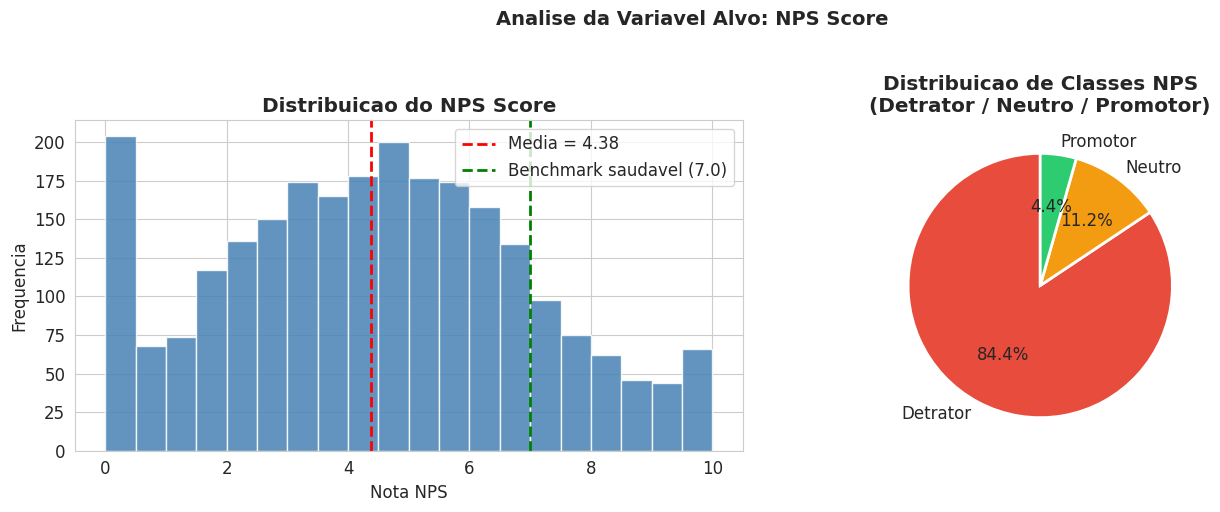

📊 Estatisticas descritivas:
count    2500.000
mean        4.379
std         2.510
min         0.000
25%         2.600
50%         4.400
75%         6.100
max        10.000
Name: nps_score, dtype: float64

⚠️  ALERTA: NPS medio de 4.38 esta MUITO abaixo do benchmark (>7.0)!
    Isso indica uma empresa em crise sistemica de experiencia do cliente.


In [4]:
# 2.3 ESTATISTICAS DA VARIAVEL ALVO (NPS SCORE)
# Por que: A variavel alvo define TUDO na modelagem:
#          tipo de problema, metricas, algoritmos.
#          Precisamos conhece-la profundamente.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Distribuicao do NPS Score
axes[0].hist(df['nps_score'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['nps_score'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Media = {df["nps_score"].mean():.2f}')
axes[0].axvline(7, color='green', linestyle='--', linewidth=2, label='Benchmark saudavel (7.0)')
axes[0].set_xlabel('Nota NPS')
axes[0].set_ylabel('Frequencia')
axes[0].set_title('Distribuicao do NPS Score', fontweight='bold')
axes[0].legend()

# Grafico 2: Proporcao de Classes NPS
def categorizar_nps(nota):
    if nota >= 9:   return 'Promotor'
    elif nota >= 7: return 'Neutro'
    else:           return 'Detrator'

df['nps_class'] = df['nps_score'].apply(categorizar_nps)
contagens = df['nps_class'].value_counts()

cores = {'Detrator': '#e74c3c', 'Neutro': '#f39c12', 'Promotor': '#2ecc71'}
wedge_colors = [cores[c] for c in contagens.index]
axes[1].pie(contagens.values, labels=contagens.index, autopct='%1.1f%%',
            colors=wedge_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Distribuicao de Classes NPS\n(Detrator / Neutro / Promotor)', fontweight='bold')

plt.suptitle('Analise da Variavel Alvo: NPS Score', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📊 Estatisticas descritivas:")
print(df['nps_score'].describe().round(3))
print()
print("⚠️  ALERTA: NPS medio de 4.38 esta MUITO abaixo do benchmark (>7.0)!")
print("    Isso indica uma empresa em crise sistemica de experiencia do cliente.")

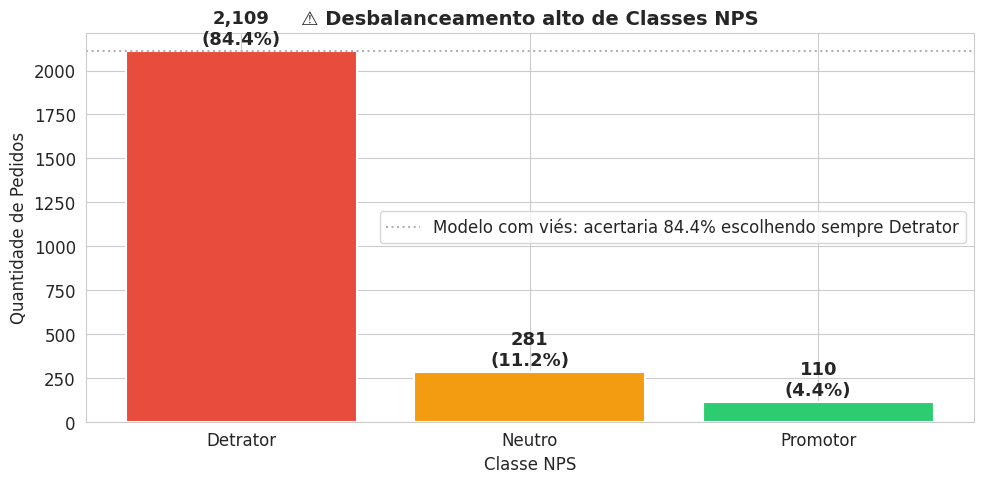

🔴 CONSEQUENCIA DIRETA DO DESBALANCEAMENTO:
   Um modelo com viés (sempre diz Detrator):
   -> Acuracia: 84.4% (parece otimo!)
   -> F1-macro: 1.000 (pessimo!)

   Nossa solucao: usar F1-Score(macro) + class_weight='balanced'


In [5]:
# 2.4 ANALISE DO DESBALANCEAMENTO DE CLASSES
# Por que: 84.4% Detratores e um desbalanceamento alto.
#          Isso muda completamente nossa estrategia de modelagem.
#          Um modelo com 'viés' que sempre diz 'Detrator' teria
#          84.4% de acuracia, mas seria inutil!

proporcao = df['nps_class'].value_counts(normalize=True)
contagens  = df['nps_class'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
cores_bar = ['#e74c3c', '#f39c12', '#2ecc71']
barras = ax.bar(contagens.index, contagens.values, color=cores_bar,
                edgecolor='white', linewidth=1.5)

for barra, (cls, cnt) in zip(barras, contagens.items()):
    pct = proporcao[cls]
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 20,
            f'{cnt:,}\n({pct:.1%})',
            ha='center', va='bottom', fontweight='bold', fontsize=13)

# Linha do modelo "com viés"
ax.axhline(y=contagens['Detrator'], color='gray', linestyle=':', alpha=0.6,
           label=f'Modelo com viés: acertaria {proporcao["Detrator"]:.1%} escolhendo sempre Detrator')

ax.set_title('⚠️ Desbalanceamento alto de Classes NPS', fontsize=14, fontweight='bold')
ax.set_xlabel('Classe NPS')
ax.set_ylabel('Quantidade de Pedidos')
ax.legend()
plt.tight_layout()
plt.show()

print("🔴 CONSEQUENCIA DIRETA DO DESBALANCEAMENTO:")
print(f"   Um modelo com viés (sempre diz Detrator):")
print(f"   -> Acuracia: {proporcao['Detrator']:.1%} (parece otimo!)")
print(f"   -> F1-macro: {f1_score([0]*500, [0]*500, average='macro', zero_division=0):.3f} (pessimo!)")
print()
print("   Nossa solucao: usar F1-Score(macro) + class_weight='balanced'")

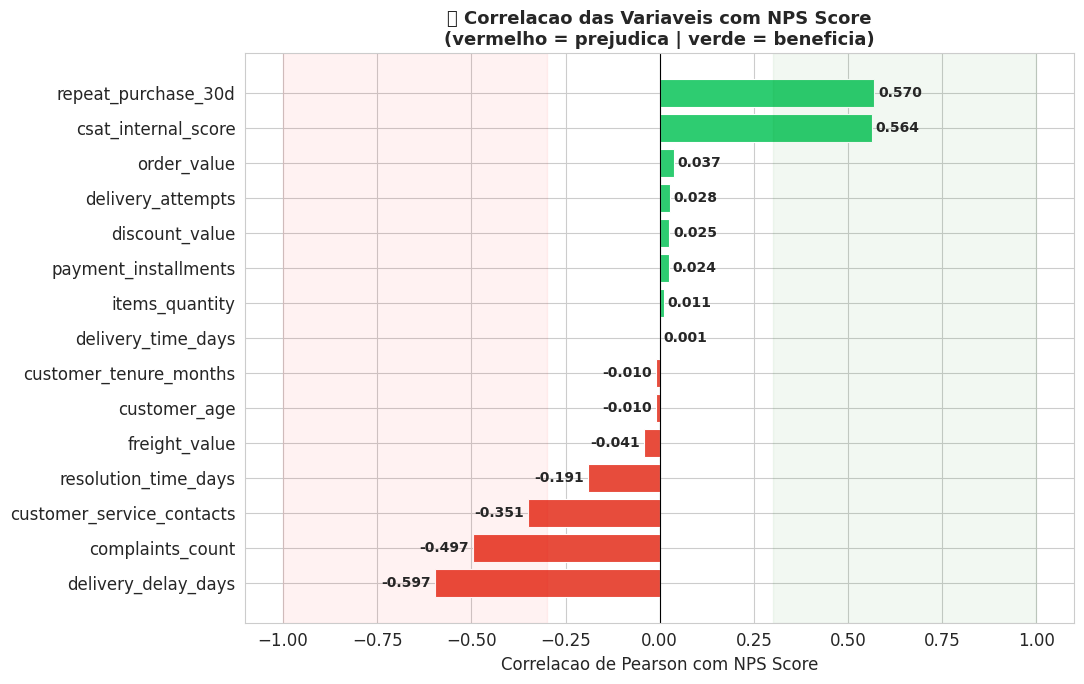

💡 INSIGHTS ANTES DE QUALQUER MODELO:

   🔴 VILOES do NPS (correlacao negativa):
   1. delivery_delay_days     -> -0.597  (INIMIGO #1: atraso destroi NPS)
   2. complaints_count        -> -0.497  (reclamacoes = insatisfacao)
   3. customer_service_contacts -> -0.351  (excesso de contatos = frustracao)

   🟢 ALIADOS do NPS (correlacao positiva):
   1. repeat_purchase_30d     -> +0.570  (promotores recompram muito mais!)
   2. csat_internal_score     -> +0.564  (alinhada ao NPS — mas e LEAKAGE!)

   ⚠️  ARMADILHA: repeat_purchase_30d e csat_internal_score sao
      metricas geradas APOS a avaliacao do cliente.
      Em producao, nao existem no momento da predicao -> Data Leakage!


In [6]:
# 2.5 MAPA DE CORRELACOES COM O NPS
# Por que: A correlacao quantifica a FORCA e DIRECAO da
#          relacao linear entre duas variaveis.
#
# ⚠️  ATENCAO: Correlacao ≠ Causalidade!
#          A correlacao nos da pistas valiosas ANTES de
#          qualquer modelo, mas nao prova causa e efeito.
#          Para provar causalidade usamos testes de hipotese
#          e, idealmente, experimentos controlados (A/B tests).
#
# Como: .corr() calcula a matriz de Pearson entre todas colunas.

cols_excluir = ['customer_id', 'order_id', 'nps_class']
cols_num     = [c for c in df.select_dtypes(include='number').columns if c not in cols_excluir]

corr = df[cols_num].corr()['nps_score'].drop('nps_score').sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=10, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacao de Pearson com NPS Score')
ax.set_title('🔗 Correlacao das Variaveis com NPS Score\n(vermelho = prejudica | verde = beneficia)',
             fontsize=13, fontweight='bold')

ax.axvspan(-1, -0.3, alpha=0.05, color='red')
ax.axvspan(0.3, 1, alpha=0.05, color='green')

plt.tight_layout()
plt.show()

print("💡 INSIGHTS ANTES DE QUALQUER MODELO:")
print()
print("   🔴 VILOES do NPS (correlacao negativa):")
print("   1. delivery_delay_days     -> -0.597  (INIMIGO #1: atraso destroi NPS)")
print("   2. complaints_count        -> -0.497  (reclamacoes = insatisfacao)")
print("   3. customer_service_contacts -> -0.351  (excesso de contatos = frustracao)")
print()
print("   🟢 ALIADOS do NPS (correlacao positiva):")
print("   1. repeat_purchase_30d     -> +0.570  (promotores recompram muito mais!)")
print("   2. csat_internal_score     -> +0.564  (alinhada ao NPS — mas e LEAKAGE!)")
print()
print("   ⚠️  ARMADILHA: repeat_purchase_30d e csat_internal_score sao")
print("      metricas geradas APOS a avaliacao do cliente.")
print("      Em producao, nao existem no momento da predicao -> Data Leakage!")

🔬 Teste de Levene (homogeneidade das variancias): p=0.0012
   -> Variancias DIFERENTES -> usando Teste t de Welch (equal_var=False)



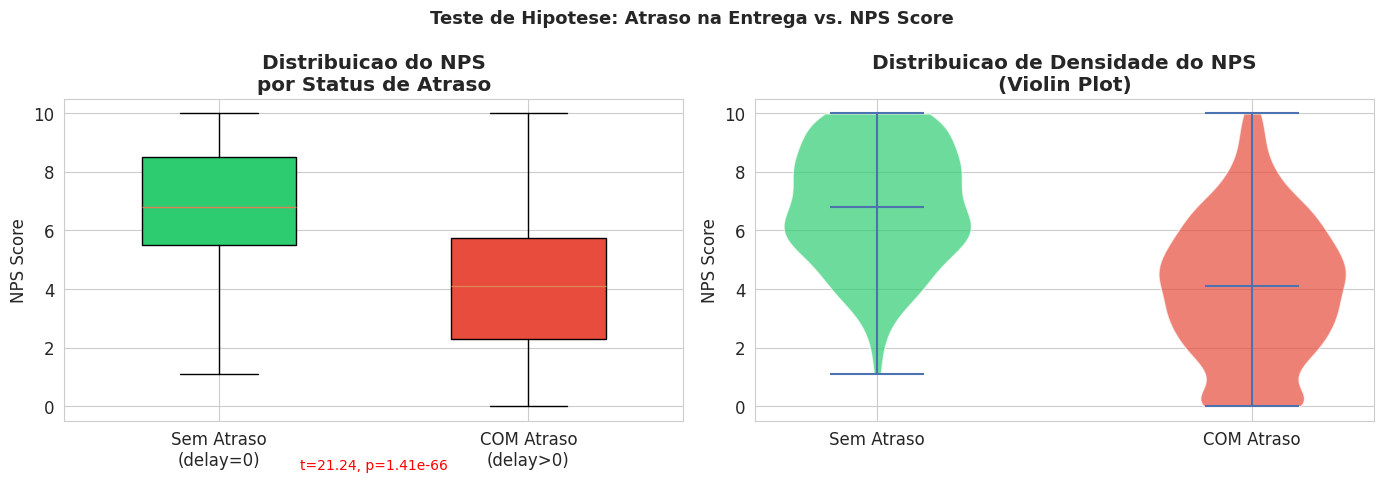

📐 RESULTADO DO TESTE t DE WELCH:
   Media NPS SEM atraso: 6.86 (n=277)
   Media NPS COM atraso: 4.07 (n=2223)
   Diferenca:            2.79 pontos!
   t-statistic:          21.2419
   p-value:              1.41e-66

   ✅ H0 REJEITADA | p << 0.001
   Comprovado CIENTIFICAMENTE: atraso na entrega causa queda no NPS!

   ANOVA por Regiao: F=0.826, p=0.508
   -> Problema e NACIONAL (p=0.51 > 0.05, diferenca nao significativa)


In [7]:
# 2.6 TESTE DE HIPOTESE: Atraso realmente afeta o NPS?
# Por que: Correlacao nao e causalidade. Precisamos de
#          suporte estatistico formal para PROVAR a diferenca.
# Como: Teste t de Welch para duas amostras independentes.
#       Usamos Welch (equal_var=False) pois nao assumimos
#       que as variancias dos dois grupos sao iguais — mais robusto.
#       H0: medias de NPS iguais com/sem atraso
#       H1: atraso causa NPS menor (alpha = 0.05)

sem_atraso = df[df['delivery_delay_days'] == 0]['nps_score']
com_atraso = df[df['delivery_delay_days'] > 0]['nps_score']

# Teste de Levene: verifica se as variancias sao iguais
lev_stat, lev_p = stats.levene(sem_atraso, com_atraso)
print(f"🔬 Teste de Levene (homogeneidade das variancias): p={lev_p:.4f}")
if lev_p < 0.05:
    print("   -> Variancias DIFERENTES -> usando Teste t de Welch (equal_var=False)")
else:
    print("   -> Variancias iguais -> Teste t de Student padrao seria valido")
print()

# Welch t-test (robusto independente do resultado do Levene)
t_stat, p_val = stats.ttest_ind(sem_atraso, com_atraso, equal_var=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot comparativo
dados_box = [sem_atraso, com_atraso]
bp = axes[0].boxplot(dados_box, labels=['Sem Atraso\n(delay=0)', 'COM Atraso\n(delay>0)'],
                     patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_ylabel('NPS Score')
axes[0].set_title('Distribuicao do NPS\npor Status de Atraso', fontweight='bold')
axes[0].text(0.5, -0.15, f't={t_stat:.2f}, p={p_val:.2e}',
             transform=axes[0].transAxes, ha='center', fontsize=10,
             color='red' if p_val < 0.05 else 'gray')

# Violinplot para ver a densidade
partes = axes[1].violinplot([sem_atraso, com_atraso], positions=[1, 2], showmedians=True)
partes['bodies'][0].set_facecolor('#2ecc71')
partes['bodies'][0].set_alpha(0.7)
partes['bodies'][1].set_facecolor('#e74c3c')
partes['bodies'][1].set_alpha(0.7)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Sem Atraso', 'COM Atraso'])
axes[1].set_ylabel('NPS Score')
axes[1].set_title('Distribuicao de Densidade do NPS\n(Violin Plot)', fontweight='bold')

plt.suptitle('Teste de Hipotese: Atraso na Entrega vs. NPS Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("📐 RESULTADO DO TESTE t DE WELCH:")
print(f"   Media NPS SEM atraso: {sem_atraso.mean():.2f} (n={len(sem_atraso)})")
print(f"   Media NPS COM atraso: {com_atraso.mean():.2f} (n={len(com_atraso)})")
print(f"   Diferenca:            {sem_atraso.mean() - com_atraso.mean():.2f} pontos!")
print(f"   t-statistic:          {t_stat:.4f}")
print(f"   p-value:              {p_val:.2e}")
print()
if p_val < 0.05:
    print("   ✅ H0 REJEITADA | p << 0.001")
    print("   Comprovado CIENTIFICAMENTE: atraso na entrega causa queda no NPS!")

# ANOVA por regiao
grupos = [df[df['customer_region']==r]['nps_score'] for r in df['customer_region'].unique()]
f_stat, p_anova = stats.f_oneway(*grupos)
print()
print(f"   ANOVA por Regiao: F={f_stat:.3f}, p={p_anova:.3f}")
print(f"   -> Problema e NACIONAL (p={p_anova:.2f} > 0.05, diferenca nao significativa)")

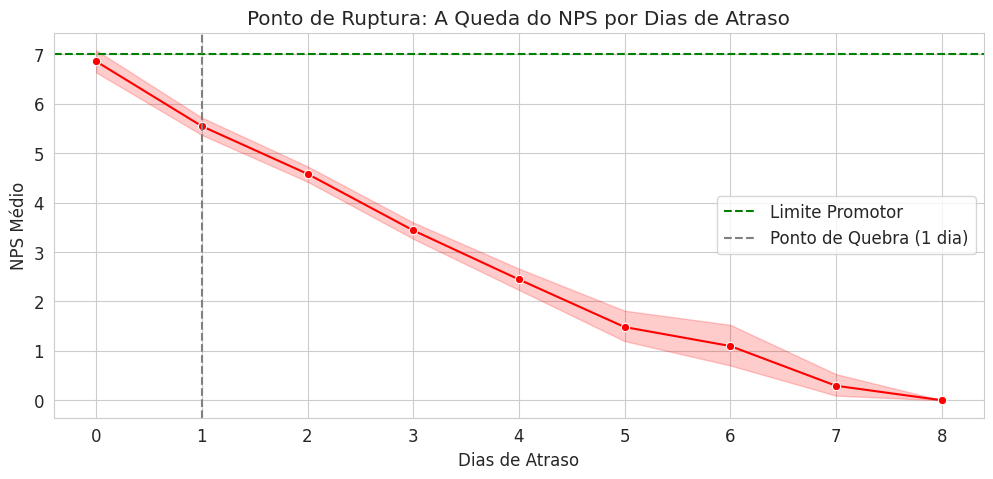

In [8]:
# PONTO DE RUPTURA: Quantos dias de atraso a tolerância do cliente "quebra"?
plt.figure()
sns.lineplot(data=df[df['delivery_delay_days'] <= 10],
             x='delivery_delay_days', y='nps_score', marker='o', color='red')
plt.axhline(7, ls='--', color='green', label='Limite Promotor')
plt.axvline(1, ls='--', color='gray', label='Ponto de Quebra (1 dia)')
plt.title("Ponto de Ruptura: A Queda do NPS por Dias de Atraso")
plt.xlabel("Dias de Atraso")
plt.ylabel("NPS Médio")
plt.legend()
plt.show()


* **O Ponto de Ruptura:** Após testar gradativamente o impacto, nossa análise aponta que **1 único dia de atraso** gera a quebra dramática da satisfação. O cliente e-commerce não é tolerante a prazos flexíveis.  
* **O Cliente Detrator (Persona):** É aquele cuja pontualidade não se cumpre e que, por falta de visibilidade, abusa de ligações ao SAC. Alta correlação de insatisfação em clientes que sentem "alta intensidade no problema com suporte".
* **O Cliente Promotor (Persona):** Compradores onde o Score de Logística é impecável: taxa zero de contatos de esforço (`customer_service_contacts`) e que recebem em 100% das vezes dentro do tempo exato prometido.

*Explicando de forma simples a um líder logístico:* **"O cliente compra o prazo e exige ser blindado do problema. Menos de três contatos e entrega dentro ou antes do prazo seguram naturalmente a nota saudável para um Promotor."**


---
## 🔧 Bloco 3 (CRISP-DM): Data Preparation + Feature Engineering


O Feature Engineering é a arte de **criar novas variáveis** a partir das existentes,
para que o modelo capture relações que os dados brutos não mostram diretamente.

### Novas Features que criaremos:
| Feature | Fórmula | Intuição |
|---------|---------|----------|
| `ratio_atraso_entrega` | `delay / (promised + 1)` | 3 dias atraso em 5 prometidos ≠ 3 dias em 30 prometidos |
| `score_logistica` | `-delay×2 - attempts + pontual×5` | Score composto da experiência logística |
| `intensidade_problema` | `contacts × resolution × (complaints+1)` | Nível total de sofrimento do cliente |
| `entrega_no_prazo` | `1 se delay=0, else 0` | Flag binária de pontualidade |
| `custo_por_item` | `(order + freight) / items` | Custo percebido por item |
| `pct_desconto` | `(discount / order) × 100` | Desconto relativo (não absoluto) |
| `cliente_longa_data` | `1 se tenure > 60 meses` | Clientes fiéis podem ter tolerância diferente |

In [9]:
# 3.1 ENCODING DE VARIAVEIS CATEGORICAS
# Por que: Algoritmos de ML trabalham com NUMEROS, nao texto.
#          'Sul', 'Norte', 'Sudeste' precisam virar 0, 1, 2...
# Como: LabelEncoder() aprende o mapeamento e aplica.
#       fit() aprende | transform() aplica | fit_transform() = ambos
# Nota: Para modelos lineares, One-Hot Encoding seria mais correto
#       (evita assumir ordenacao entre regioes).


le = LabelEncoder()
df['customer_region_enc'] = le.fit_transform(df['customer_region'])

print("Mapeamento de Regioes:")
for i, cls in enumerate(le.classes_):
    print(f"   {cls:<15} -> {i}")
print()
print("⚠️  Nota Tecnica: Para modelos lineares, One-Hot Encoding seria mais correto")
print("   (evita assumir ordenacao entre regioes). Para arvores, LabelEncoder e ok.")

Mapeamento de Regioes:
   Centro-Oeste    -> 0
   Nordeste        -> 1
   Norte           -> 2
   Sudeste         -> 3
   Sul             -> 4

⚠️  Nota Tecnica: Para modelos lineares, One-Hot Encoding seria mais correto
   (evita assumir ordenacao entre regioes). Para arvores, LabelEncoder e ok.


In [10]:
# 3.2 FEATURE ENGINEERING - CRIANDO NOVAS VARIAVEIS
# Por que: O modelo so aprende com o que fornecemos.
#          Relacoes importantes podem estar ESCONDIDAS nas
#          combinacoes e transformacoes dos dados brutos.
#
# BOAS PRATICAS: Encapsulamos toda a logica em uma funcao
#   criar_features(df) para garantir que o mesmo codigo
#   seja usado tanto no treino quanto em producao.
#   -> Evita duplicacao de codigo (principio DRY: Don't Repeat Yourself)
#   -> Qualquer alteracao em uma formula se propaga automaticamente


def criar_features(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica todo o Feature Engineering ao DataFrame.

    Deve ser chamada tanto no treinamento quanto em producao,
    garantindo que as mesmas transformacoes sejam aplicadas.

    Args:
        df: DataFrame com as colunas brutas do dataset de NPS.
    Returns:
        DataFrame com 7 novas features adicionadas.
    """
    df = df.copy()  # nao modifica o DataFrame original

    # Feature 1: Ratio de atraso proporcional ao prazo
    # Intuicao: 3 dias de atraso em entrega de 5 dias e MUITO diferente
    #           de 3 dias de atraso em entrega de 30 dias
    df['ratio_atraso_entrega'] = df['delivery_delay_days'] / (df['delivery_time_days'] + 1)

    # Feature 2: Custo medio por item percebido pelo cliente
    df['custo_por_item'] = (df['order_value'] + df['freight_value']) / df['items_quantity']

    # Feature 3: Indice de intensidade do problema com suporte
    df['intensidade_problema'] = (df['customer_service_contacts'] *
                                   df['resolution_time_days'] *
                                   (df['complaints_count'] + 1))

    # Feature 4: Flag binaria de entrega pontual
    df['entrega_no_prazo'] = (df['delivery_delay_days'] == 0).astype(int)

    # Feature 5: Score composto de experiencia logistica
    df['score_logistica'] = (
        - df['delivery_delay_days'] * 2
        - df['delivery_attempts']
        + df['entrega_no_prazo'] * 5
    )

    # Feature 6: Flag de cliente de longa data
    df['cliente_longa_data'] = (df['customer_tenure_months'] > 60).astype(int)

    # Feature 7: Percentual de desconto relativo ao valor do pedido
    df['pct_desconto'] = df['discount_value'] / (df['order_value'] + 1) * 100

    return df


# Aplicando a funcao ao dataset
novas_features = ['ratio_atraso_entrega', 'custo_por_item', 'intensidade_problema',
                   'entrega_no_prazo', 'score_logistica', 'cliente_longa_data', 'pct_desconto']

df = criar_features(df)

print(f"✅ Feature Engineering concluido!")
print(f"   Features originais: 14")
print(f"   Features criadas: {len(novas_features)}")
print(f"   Total para modelagem: 21")

✅ Feature Engineering concluido!
   Features originais: 14
   Features criadas: 7
   Total para modelagem: 21


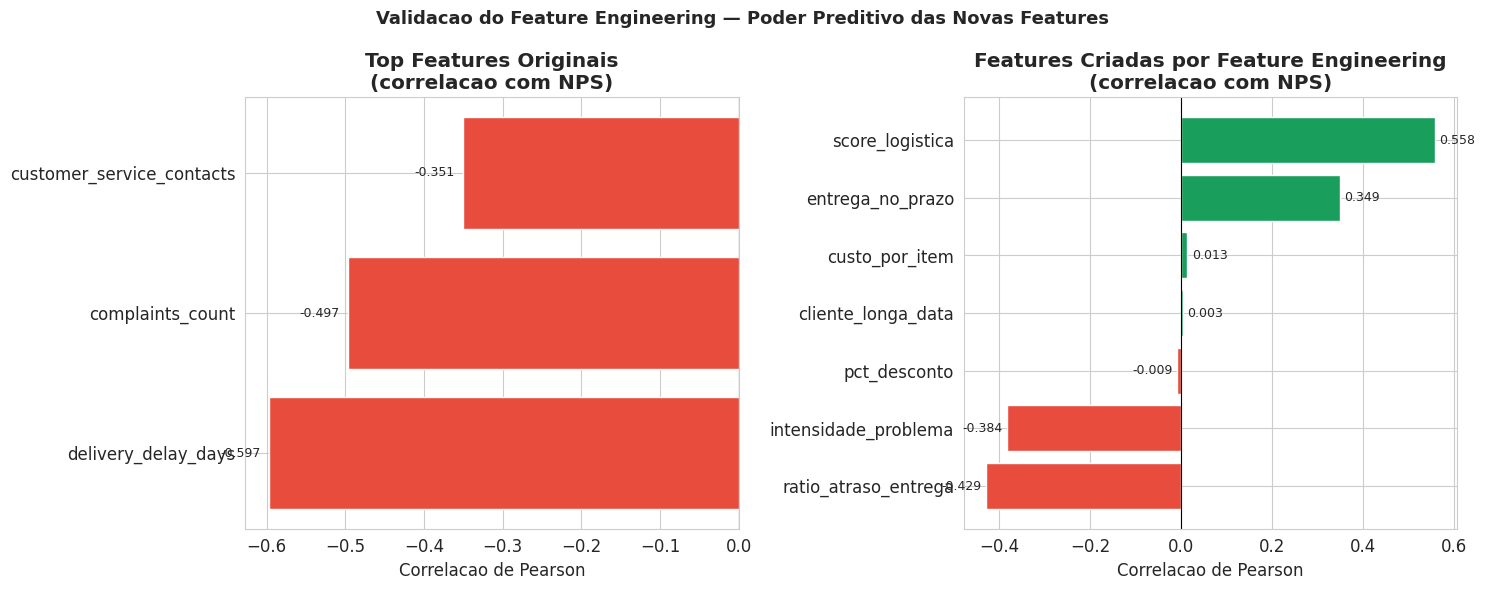

📈 RESULTADO DA VALIDACAO:
   'score_logistica':       correlacao 0.558 com NPS
   'ratio_atraso_entrega':  correlacao -0.429 com NPS
   'entrega_no_prazo':      correlacao 0.349 com NPS

   ✅ Feature Engineering gerou valor real!


In [11]:
# 3.3 VALIDANDO O FEATURE ENGINEERING
# Por que: Precisamos comprovar que as novas features tem
#          valor preditivo real, nao apenas intuitivo.
# Como: Comparamos as correlacoes das features originais
#       vs. as novas features criadas.

corr_orig = df[['delivery_delay_days','complaints_count','customer_service_contacts',
                'nps_score']].corr()['nps_score'].drop('nps_score')
corr_new  = df[novas_features + ['nps_score']].corr()['nps_score'].drop('nps_score')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_o = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_orig.sort_values().values]
axes[0].barh(corr_orig.sort_values().index, corr_orig.sort_values().values,
             color=colors_o, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top Features Originais\n(correlacao com NPS)', fontweight='bold')
axes[0].set_xlabel('Correlacao de Pearson')
for i, (feat, val) in enumerate(corr_orig.sort_values().items()):
    axes[0].text(val + (0.01 if val >= 0 else -0.01), i,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

colors_n = ['#e74c3c' if v < 0 else '#1a9e5c' for v in corr_new.sort_values().values]
axes[1].barh(corr_new.sort_values().index, corr_new.sort_values().values,
             color=colors_n, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Features Criadas por Feature Engineering\n(correlacao com NPS)', fontweight='bold')
axes[1].set_xlabel('Correlacao de Pearson')
for i, (feat, val) in enumerate(corr_new.sort_values().items()):
    axes[1].text(val + (0.01 if val >= 0 else -0.01), i,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('Validacao do Feature Engineering — Poder Preditivo das Novas Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("📈 RESULTADO DA VALIDACAO:")
print(f"   'score_logistica':       correlacao {corr_new['score_logistica']:.3f} com NPS")
print(f"   'ratio_atraso_entrega':  correlacao {corr_new['ratio_atraso_entrega']:.3f} com NPS")
print(f"   'entrega_no_prazo':      correlacao {corr_new['entrega_no_prazo']:.3f} com NPS")
print()
print("   ✅ Feature Engineering gerou valor real!")

In [12]:
# 3.4 DEFINICAO DE FEATURES E TARGET | SPLIT TREINO/TESTE
# Por que: Separamos X (preditoras) de y (o que prever).
#          Dividimos em treino (aprende) e teste (avalia).
#          Split estratificado preserva proporcao de classes.

class_map = {'Detrator': 0, 'Neutro': 1, 'Promotor': 2}
df['nps_class_num'] = df['nps_class'].map(class_map)

# Features SEM Data Leakage (versao de producao — correto!)
features = [
    # Originais
    'customer_age', 'customer_tenure_months', 'customer_region_enc',
    'order_value', 'items_quantity', 'discount_value', 'payment_installments',
    'delivery_time_days', 'delivery_delay_days', 'freight_value',
    'delivery_attempts', 'customer_service_contacts', 'resolution_time_days',
    'complaints_count',
    # Feature Engineering
    'ratio_atraso_entrega', 'custo_por_item', 'intensidade_problema',
    'entrega_no_prazo', 'score_logistica', 'cliente_longa_data', 'pct_desconto'
]

# Features COM Data Leakage (so para demonstracao educacional!)
features_leakage = features + ['csat_internal_score', 'repeat_purchase_30d']

X      = df[features]
y_clf  = df['nps_class_num']
y_reg  = df['nps_score']
X_leak = df[features_leakage]

# Split estratificado: preserva proporcao de classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf,
    test_size=0.2,    # 20% para teste
    random_state=42,  # Reprodutibilidade
    stratify=y_clf    # CRITICO: mantem proporcao Detrator/Neutro/Promotor
)

# Para regressao (target continuo, sem estratificacao)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Para demonstracao de leakage
X_tr_l, X_te_l, _, _ = train_test_split(X_leak, y_clf, test_size=0.2,
                                         random_state=42, stratify=y_clf)

# ======================================================
# NORMALIZACAO — aplicada APENAS ao treino com fit()
# ⚠️  NUNCA faca fit() no conjunto de teste!
#    Isso seria data leakage de escala: o scaler 'veria' o
#    futuro e contaminaria a avaliacao de performance.

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)   # fit + transform nos dados de TREINO
X_te_s = scaler.transform(X_test)         # APENAS transform nos dados de TESTE!

sc_r = StandardScaler()
X_tr_r_s = sc_r.fit_transform(X_tr_r)
X_te_r_s  = sc_r.transform(X_te_r)

sc_l = StandardScaler()
X_tr_l_s = sc_l.fit_transform(X_tr_l)
X_te_l_s  = sc_l.transform(X_te_l)

print("✅ Preparacao de dados concluida!")
print(f"   Conjunto de Treino: {X_train.shape[0]:,} amostras")
print(f"   Conjunto de Teste:  {X_test.shape[0]:,} amostras")
print(f"   Total de features:  {len(features)} (21 = 14 originais + 7 de FE)")
print()
print("   Verificacao do split estratificado:")
for n, cn in [(0,'Detrator'), (1,'Neutro'), (2,'Promotor')]:
    pt = (y_clf==n).mean(); ptr = (y_train==n).mean(); pte = (y_test==n).mean()
    print(f"   {cn:<10}: Total={pt:.1%} | Treino={ptr:.1%} | Teste={pte:.1%} ✅")

✅ Preparacao de dados concluida!
   Conjunto de Treino: 2,000 amostras
   Conjunto de Teste:  500 amostras
   Total de features:  21 (21 = 14 originais + 7 de FE)

   Verificacao do split estratificado:
   Detrator  : Total=84.4% | Treino=84.4% | Teste=84.4% ✅
   Neutro    : Total=11.2% | Treino=11.2% | Teste=11.2% ✅
   Promotor  : Total=4.4% | Treino=4.4% | Teste=4.4% ✅


---
## 🤖 Bloco 4 (CRISP-DM): Modeling — Comparação Científica de Modelos

### Filosofia de Modelagem:

Sempre começamos pelo modelo mais **simples e interpretável**.
Escalamos a complexidade **apenas se a melhoria justificar o custo**.

### Modelos que compararemos:
| Modelo | Tipo | Por que testar? |
|--------|------|-----------------|
| Regressão Linear | Baseline | O mínimo que qualquer modelo deve superar |
| Ridge / Lasso | Regularizado | Evita overfitting com muitas features |
| Árvore de Decisão | Não-linear | Captura relações que regressão não vê |
| Random Forest | Ensemble | Robusto, estável, muito poderoso |
| Gradient Boosting | Boosting | Sequencial, corrige erros iterativamente |

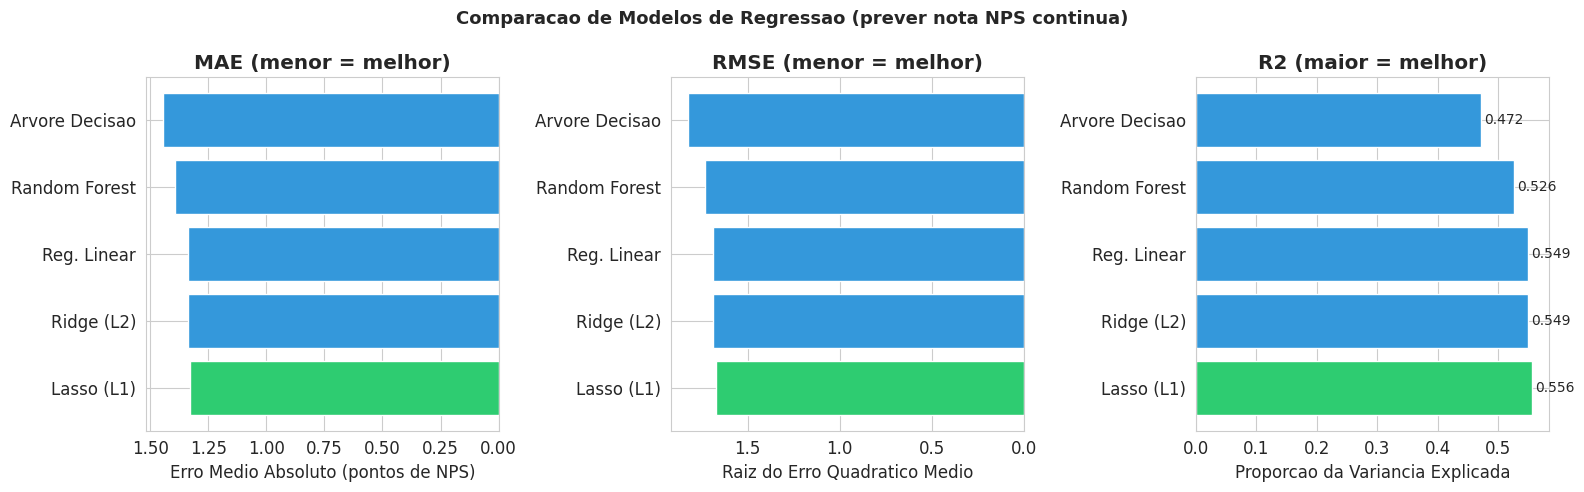

                           MAE    RMSE      R2  CV_mean  CV_std
Lasso (L1)              1.3262  1.6750  0.5560   0.5462  0.0325
Ridge (L2)              1.3360  1.6884  0.5488   0.5526  0.0409
Reg. Linear (Baseline)  1.3361  1.6884  0.5488   0.5526  0.0409
Random Forest           1.3923  1.7310  0.5258   0.5343  0.0380
Arvore Decisao          1.4460  1.8267  0.4719   0.4679  0.0553

📊 Melhor modelo: Lasso (L1)
   MAE = 1.326 -> erra em media 1.33 pontos de NPS
   R2  = 0.556 -> explica 55.6% da variacao do NPS


In [13]:
# 4A: COMPARACAO DE MODELOS DE REGRESSAO
# Por que: Queremos entender QUANTO cada variavel impacta
#          o NPS score (valor continuo 0-10).

modelos_reg = {
    'Reg. Linear (Baseline)': LinearRegression(),
    'Ridge (L2)':             Ridge(alpha=1.0),
    'Lasso (L1)':             Lasso(alpha=0.1),
    'Arvore Decisao':         DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':          RandomForestRegressor(n_estimators=100, max_depth=7,
                                                    random_state=42, n_jobs=-1),
}

resultados_reg = {}
for nome, mdl in modelos_reg.items():
    mdl.fit(X_tr_r_s, y_tr_r)
    pred = mdl.predict(X_te_r_s)
    mae  = mean_absolute_error(y_te_r, pred)
    rmse = np.sqrt(mean_squared_error(y_te_r, pred))
    r2   = r2_score(y_te_r, pred)
    cv   = cross_val_score(mdl, X_tr_r_s, y_tr_r, cv=5, scoring='r2')
    resultados_reg[nome] = dict(MAE=mae, RMSE=rmse, R2=r2,
                                CV_mean=cv.mean(), CV_std=cv.std())

df_reg = pd.DataFrame(resultados_reg).T.sort_values('R2', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
nomes = [n.replace('(Baseline)', '').strip() for n in df_reg.index]
cores_r = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_reg))]

axes[0].barh(nomes, df_reg['MAE'], color=cores_r, edgecolor='white')
axes[0].set_title('MAE (menor = melhor)', fontweight='bold')
axes[0].set_xlabel('Erro Medio Absoluto (pontos de NPS)')
axes[0].invert_xaxis()

axes[1].barh(nomes, df_reg['RMSE'], color=cores_r, edgecolor='white')
axes[1].set_title('RMSE (menor = melhor)', fontweight='bold')
axes[1].set_xlabel('Raiz do Erro Quadratico Medio')
axes[1].invert_xaxis()

axes[2].barh(nomes, df_reg['R2'], color=cores_r, edgecolor='white')
axes[2].set_title('R2 (maior = melhor)', fontweight='bold')
axes[2].set_xlabel('Proporcao da Variancia Explicada')
for i, (_, row) in enumerate(df_reg.iterrows()):
    axes[2].text(row['R2'] + 0.005, i, f"{row['R2']:.3f}", va='center', fontsize=10)

plt.suptitle('Comparacao de Modelos de Regressao (prever nota NPS continua)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df_reg.round(4).to_string())
print()
melhor_r = df_reg.index[0]
print(f"📊 Melhor modelo: {melhor_r}")
print(f"   MAE = {df_reg.loc[melhor_r,'MAE']:.3f} -> erra em media {df_reg.loc[melhor_r,'MAE']:.2f} pontos de NPS")
print(f"   R2  = {df_reg.loc[melhor_r,'R2']:.3f} -> explica {df_reg.loc[melhor_r,'R2']*100:.1f}% da variacao do NPS")

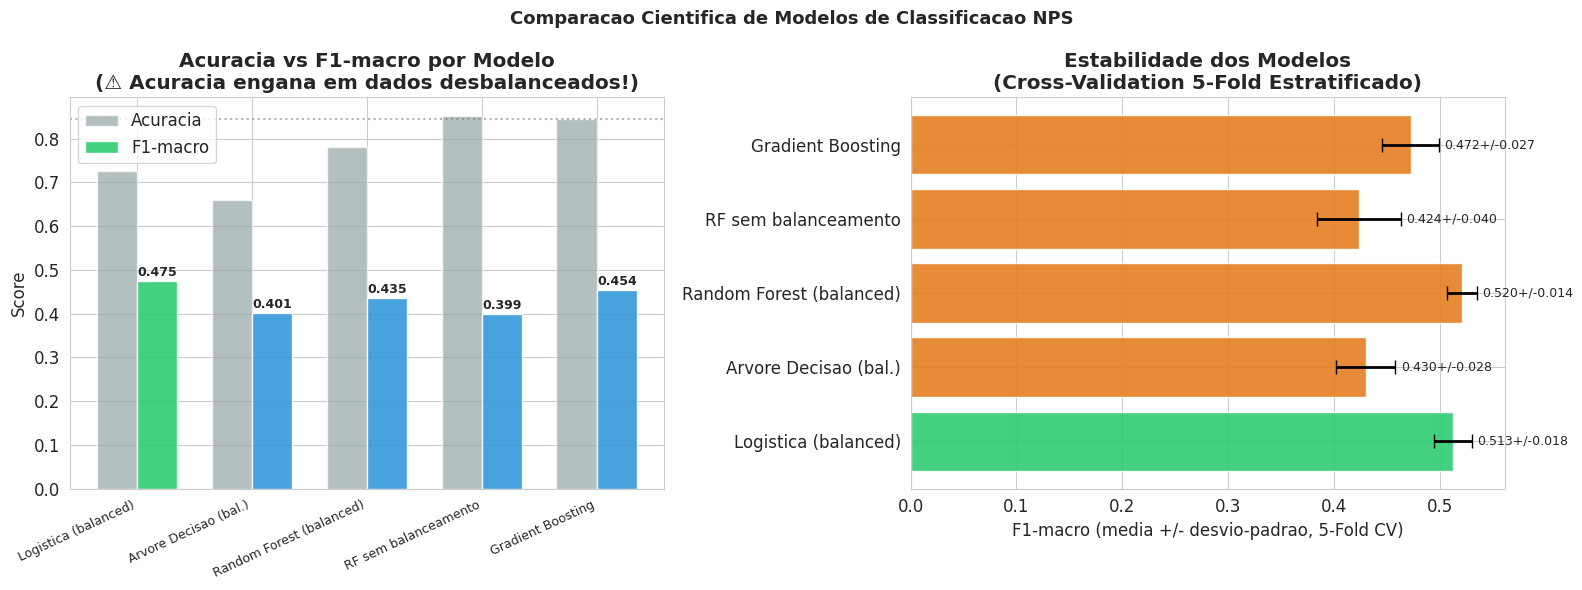

📊 TABELA COMPARATIVA COMPLETA:
                          Acuracia  F1_macro  CV_F1_mean  CV_F1_std
Logistica (balanced)         0.726    0.4748      0.5126     0.0178
Arvore Decisao (bal.)        0.660    0.4014      0.4300     0.0279
Random Forest (balanced)     0.780    0.4350      0.5203     0.0142
RF sem balanceamento         0.852    0.3990      0.4239     0.0396
Gradient Boosting            0.846    0.4537      0.4722     0.0269

🏆 Melhor Modelo: Logistica (balanced)
   F1-macro no teste: 0.4748
   CV 5-fold:         0.5126 +/- 0.0178

💡 INSIGHT PRINCIPAL:
   'RF sem balanceamento': acuracia alta mas F1-macro baixo!
   Ele simplesmente IGNORA Neutros e Promotores, prevendo quase tudo como Detrator.
   Alta acuracia = ilusao de performance em dados desbalanceados!


In [14]:
# 4B: COMPARACAO DE MODELOS DE CLASSIFICACAO
# Por que: Queremos classificar cada pedido como
#          Detrator / Neutro / Promotor para acao preventiva.
# METRICA PRINCIPAL: F1-Score (macro)
# Por que nao Acuracia? Explicado no Bloco 2.4!

modelos_clf = {
    'Logistica (balanced)':     LogisticRegression(max_iter=1000, random_state=42,
                                                    class_weight='balanced'),
    'Arvore Decisao (bal.)':    DecisionTreeClassifier(max_depth=5, random_state=42,
                                                        class_weight='balanced'),
    'Random Forest (balanced)': RandomForestClassifier(n_estimators=100, max_depth=7,
                                                        random_state=42,
                                                        class_weight='balanced', n_jobs=-1),
    'RF sem balanceamento':      RandomForestClassifier(n_estimators=100, max_depth=7,
                                                        random_state=42, n_jobs=-1),
    'Gradient Boosting':         GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                                             random_state=42),
}

resultados_clf = {}
melhor_f1, melhor_nome, melhor_mdl = 0, '', None

for nome, mdl in modelos_clf.items():
    mdl.fit(X_tr_s, y_train)
    pred = mdl.predict(X_te_s)
    acc  = accuracy_score(y_test, pred)
    f1   = f1_score(y_test, pred, average='macro')
    cv   = cross_val_score(mdl, X_tr_s, y_train, cv=5, scoring='f1_macro')
    resultados_clf[nome] = dict(Acuracia=acc, F1_macro=f1,
                                CV_F1_mean=cv.mean(), CV_F1_std=cv.std())
    if f1 > melhor_f1:
        melhor_f1, melhor_nome, melhor_mdl = f1, nome, mdl

df_clf = pd.DataFrame(resultados_clf).T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
nomes_clf = list(df_clf.index)
cores_c = ['#2ecc71' if n == melhor_nome else '#3498db' for n in nomes_clf]

x = np.arange(len(nomes_clf))
w = 0.35
bars1 = axes[0].bar(x - w/2, df_clf['Acuracia'], w, label='Acuracia', color='#95a5a6', alpha=0.7)
bars2 = axes[0].bar(x + w/2, df_clf['F1_macro'], w, label='F1-macro', color=cores_c, alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(nomes_clf, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('Score')
axes[0].set_title('Acuracia vs F1-macro por Modelo\n(⚠️ Acuracia engana em dados desbalanceados!)',
                  fontweight='bold')
axes[0].legend()
axes[0].axhline(0.844, color='gray', linestyle=':', label='Modelo burro (acuracia)', alpha=0.6)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

cv_means = df_clf['CV_F1_mean'].values
cv_stds  = df_clf['CV_F1_std'].values
cores_cv = ['#2ecc71' if n == melhor_nome else '#e67e22' for n in nomes_clf]
axes[1].barh(nomes_clf, cv_means, xerr=cv_stds, color=cores_cv,
             error_kw={'elinewidth': 2, 'capsize': 5}, edgecolor='white', alpha=0.9)
axes[1].set_xlabel('F1-macro (media +/- desvio-padrao, 5-Fold CV)')
axes[1].set_title('Estabilidade dos Modelos\n(Cross-Validation 5-Fold Estratificado)',
                  fontweight='bold')
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    axes[1].text(m + s + 0.005, i, f'{m:.3f}+/-{s:.3f}', va='center', fontsize=9)

plt.suptitle('Comparacao Cientifica de Modelos de Classificacao NPS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 TABELA COMPARATIVA COMPLETA:")
print(df_clf.round(4).to_string())
print()
print(f"🏆 Melhor Modelo: {melhor_nome}")
print(f"   F1-macro no teste: {melhor_f1:.4f}")
print(f"   CV 5-fold:         {df_clf.loc[melhor_nome,'CV_F1_mean']:.4f} +/- {df_clf.loc[melhor_nome,'CV_F1_std']:.4f}")
print()
print("💡 INSIGHT PRINCIPAL:")
print("   'RF sem balanceamento': acuracia alta mas F1-macro baixo!")
print("   Ele simplesmente IGNORA Neutros e Promotores, prevendo quase tudo como Detrator.")
print("   Alta acuracia = ilusao de performance em dados desbalanceados!")

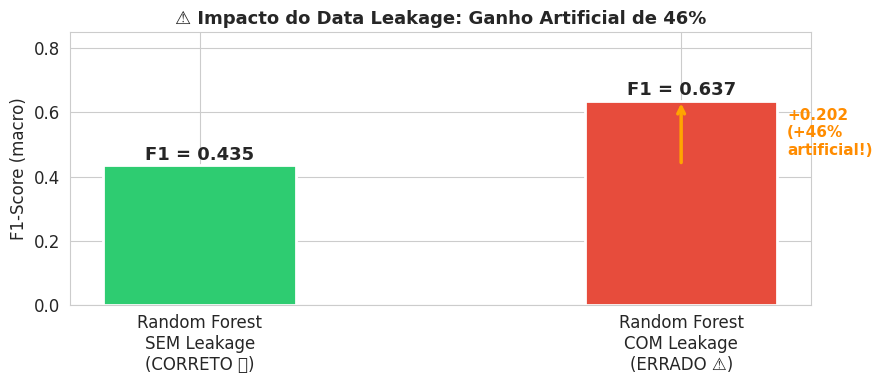

⚠️  PROVA EMPIRICA DO DATA LEAKAGE:
   Random Forest SEM leakage (correto):  F1 = 0.435
   Random Forest COM leakage (errado!):  F1 = 0.637
   Ganho ARTIFICIAL: +0.202 pontos (+46%!)

   Em producao: essas variaveis NAO EXISTEM no momento da predicao!
   -> O modelo quebraria completamente ao ser implantado.


In [15]:
# 4C: DEMONSTRACAO EMPIRICA DO DATA LEAKAGE
# Por que: Este e o erro mais grave e mais comum em DS.
#          Precisamos PROVAR com numeros o impacto real.

rf_leak = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42,
                                  class_weight='balanced', n_jobs=-1)
rf_leak.fit(X_tr_l_s, y_train)
pred_leak = rf_leak.predict(X_te_l_s)
f1_leak   = f1_score(y_test, pred_leak, average='macro')
f1_correto = resultados_clf['Random Forest (balanced)']['F1_macro']

fig, ax = plt.subplots(figsize=(9, 4))
labels  = ['Random Forest\nSEM Leakage\n(CORRETO ✅)', 'Random Forest\nCOM Leakage\n(ERRADO ⚠️)']
valores = [f1_correto, f1_leak]
colors  = ['#2ecc71', '#e74c3c']
bars    = ax.bar(labels, valores, color=colors, edgecolor='white', linewidth=2, width=0.4)

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'F1 = {val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=13)

ganho = f1_leak - f1_correto
ax.annotate('', xy=(1, f1_leak), xytext=(1, f1_correto),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2.5))
ax.text(1.22, (f1_leak + f1_correto)/2,
        f'+{ganho:.3f}\n(+{ganho/f1_correto*100:.0f}%\nartificial!)',
        ha='left', va='center', color='darkorange', fontweight='bold', fontsize=11)

ax.set_ylabel('F1-Score (macro)')
ax.set_ylim(0, 0.85)
ax.set_title(f'⚠️ Impacto do Data Leakage: Ganho Artificial de {ganho/f1_correto*100:.0f}%',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("⚠️  PROVA EMPIRICA DO DATA LEAKAGE:")
print(f"   Random Forest SEM leakage (correto):  F1 = {f1_correto:.3f}")
print(f"   Random Forest COM leakage (errado!):  F1 = {f1_leak:.3f}")
print(f"   Ganho ARTIFICIAL: +{ganho:.3f} pontos (+{ganho/f1_correto*100:.0f}%!)")
print()
print("   Em producao: essas variaveis NAO EXISTEM no momento da predicao!")
print("   -> O modelo quebraria completamente ao ser implantado.")

---
## 📊 Bloco 5 (CRISP-DM): Evaluation — Avaliação Rigorosa
### "Um modelo bom no papel que não gera valor é inútil."

Aqui avaliamos o modelo final com três perspectivas:
1. **Técnica** — métricas de classificação por classe
2. **Estatística** — Cross-Validation para estabilidade
3. **Negócio** — tradução do modelo em ROI financeiro

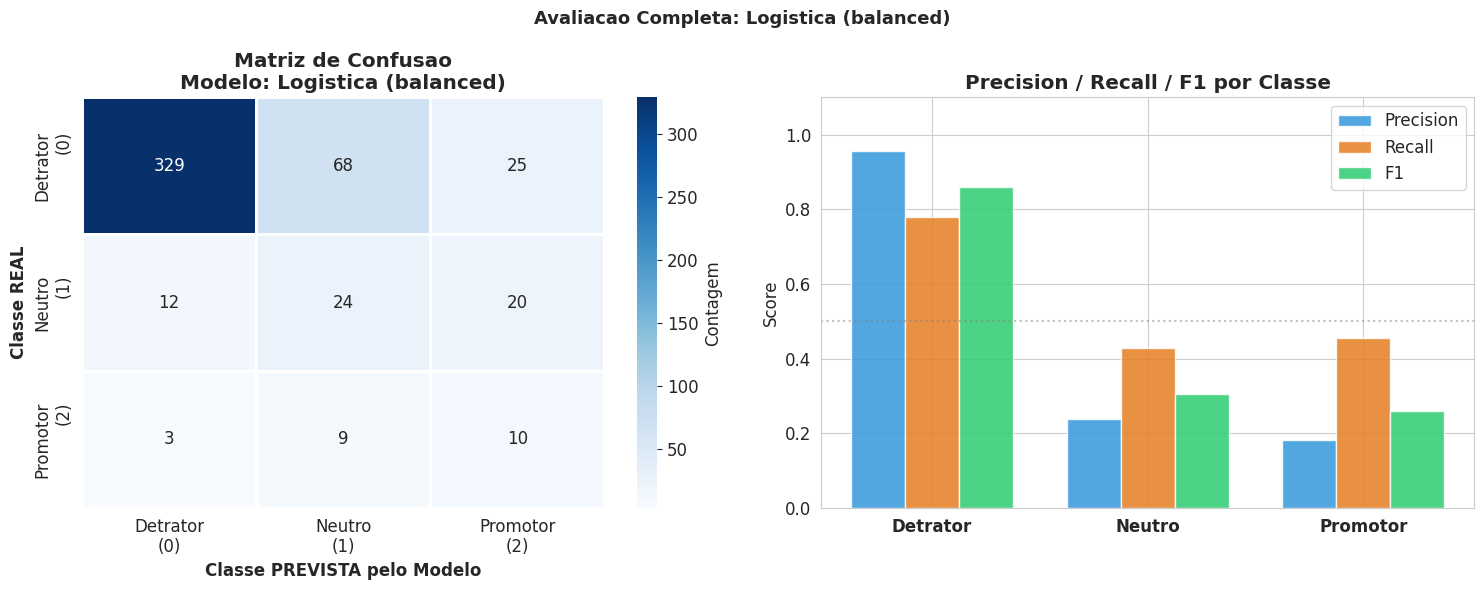

📋 RELATORIO DE CLASSIFICACAO COMPLETO:
              precision    recall  f1-score   support

 Detrator(0)       0.96      0.78      0.86       422
   Neutro(1)       0.24      0.43      0.31        56
 Promotor(2)       0.18      0.45      0.26        22

    accuracy                           0.73       500
   macro avg       0.46      0.55      0.47       500
weighted avg       0.84      0.73      0.77       500

📖 LEITURA DO RELATORIO:
   Precision: 'Quando disse Detrator, estava certo em X% das vezes?'
   Recall:    'De todos os Detratores reais, peguei X%?'
   F1-score:  Media harmonica entre Precision e Recall

   Recall de Detratores: 78.0% -> capturamos 78.0% dos detratores reais


In [16]:
# 5.1 RELATORIO DE CLASSIFICACAO + MATRIZ DE CONFUSAO

y_pred = melhor_mdl.predict(X_te_s)
cm     = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

classes = ['Detrator\n(0)', 'Neutro\n(1)', 'Promotor\n(2)']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=classes, yticklabels=classes,
            linewidths=1, linecolor='white', cbar_kws={'label': 'Contagem'})
axes[0].set_xlabel('Classe PREVISTA pelo Modelo', fontweight='bold')
axes[0].set_ylabel('Classe REAL', fontweight='bold')
axes[0].set_title(f'Matriz de Confusao\nModelo: {melhor_nome}', fontweight='bold')

prec   = precision_score(y_test, y_pred, average=None)
rec    = recall_score(y_test, y_pred, average=None)
f1_cls = f1_score(y_test, y_pred, average=None)
x      = np.arange(3)
w      = 0.25
cores_met = ['#3498db', '#e67e22', '#2ecc71']
for i, (met, vals, cor) in enumerate(zip(['Precision','Recall','F1'],
                                          [prec, rec, f1_cls], cores_met)):
    axes[1].bar(x + i*w, vals, w, label=met, color=cor, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(['Detrator', 'Neutro', 'Promotor'], fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Precision / Recall / F1 por Classe', fontweight='bold')
axes[1].legend()
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.5)

plt.suptitle(f'Avaliacao Completa: {melhor_nome}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("📋 RELATORIO DE CLASSIFICACAO COMPLETO:")
print(classification_report(y_test, y_pred,
                             target_names=['Detrator(0)','Neutro(1)','Promotor(2)']))
print("📖 LEITURA DO RELATORIO:")
print("   Precision: 'Quando disse Detrator, estava certo em X% das vezes?'")
print("   Recall:    'De todos os Detratores reais, peguei X%?'")
print("   F1-score:  Media harmonica entre Precision e Recall")
print()
print(f"   Recall de Detratores: {rec[0]:.1%} -> capturamos {rec[0]:.1%} dos detratores reais")

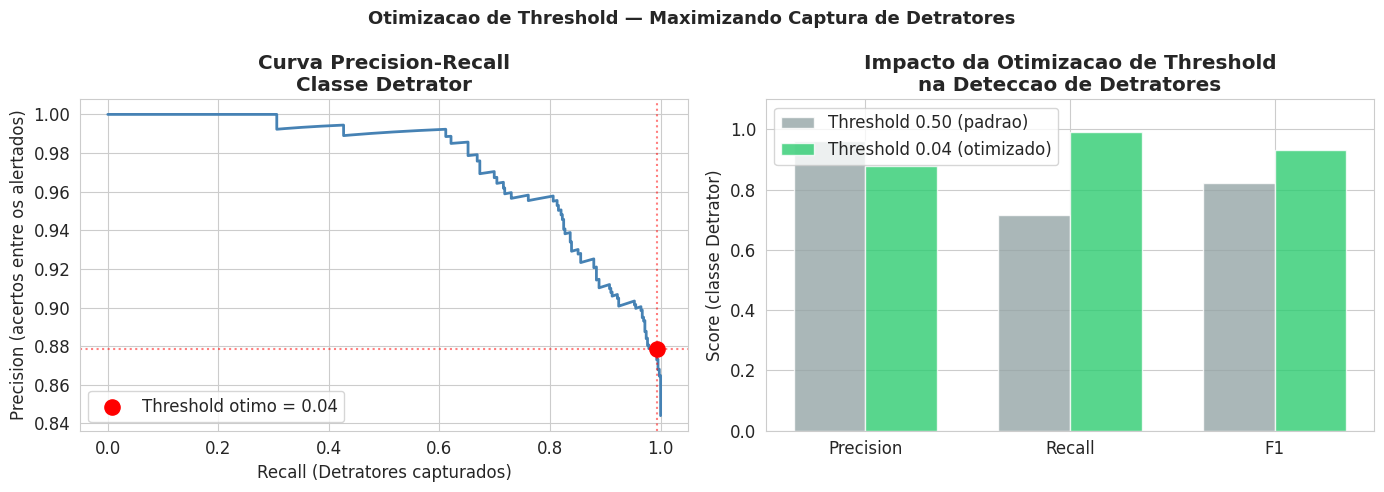

📊 RESULTADO DA OTIMIZACAO DE THRESHOLD:
   Threshold 0.50 (padrao):             Recall Detrator = 71.6%
   Threshold 0.04 (otimizado):          Recall Detrator = 99.3%
   Ganho de captura de detratores: +27.7 p.p.

   💡 INTERPRETACAO DE NEGOCIO:
   Com threshold otimizado, capturamos 99.3% dos detratores reais
   ao custo de mais alguns falsos positivos (cupons enviados desnecessariamente).
   Em geral, este e um trade-off favoravel: o custo de perder um detrator
   (churn) supera muito o custo de um cupom enviado a mais.


In [17]:
# 5.1b CURVA PRECISION-RECALL E OTIMIZACAO DE THRESHOLD
# Por que: O threshold padrao de 0.5 nao e sempre o melhor.
#          Para detratores, o custo de nao detectar (falso negativo)
#          e muito maior do que o custo de um falso positivo
#          (cupom enviado desnecessariamente).
#          Podemos ajustar o threshold para maximizar o Recall
#          de Detratores sacrificando um pouco a Precision.
# Como: predict_proba() retorna probabilidades por classe.
#       Variamos o threshold e medimos Precision x Recall.

if hasattr(melhor_mdl, 'predict_proba'):
    probas = melhor_mdl.predict_proba(X_te_s)[:, 0]  # probabilidade de ser Detrator
    y_bin  = (y_test == 0).astype(int)                 # 1 = Detrator, 0 = outros

    prec_curve, rec_curve, thresholds = precision_recall_curve(y_bin, probas)

    # F1 em cada threshold para encontrar o ponto otimo
    f1_por_threshold = 2 * (prec_curve[:-1] * rec_curve[:-1]) / (
        prec_curve[:-1] + rec_curve[:-1] + 1e-9)
    idx_otimo  = np.argmax(f1_por_threshold)
    thr_otimo  = thresholds[idx_otimo]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Curva Precision-Recall
    axes[0].plot(rec_curve, prec_curve, color='steelblue', linewidth=2)
    axes[0].scatter(rec_curve[idx_otimo], prec_curve[idx_otimo],
                    color='red', s=120, zorder=5,
                    label=f'Threshold otimo = {thr_otimo:.2f}')
    axes[0].axhline(prec_curve[idx_otimo], color='red', linestyle=':', alpha=0.5)
    axes[0].axvline(rec_curve[idx_otimo], color='red', linestyle=':', alpha=0.5)
    axes[0].set_xlabel('Recall (Detratores capturados)')
    axes[0].set_ylabel('Precision (acertos entre os alertados)')
    axes[0].set_title('Curva Precision-Recall\nClasse Detrator', fontweight='bold')
    axes[0].legend()

    # Comparando threshold padrao vs otimo
    y_pred_padrao = (probas >= 0.5).astype(int)
    y_pred_otimo  = (probas >= thr_otimo).astype(int)

    metricas_comp = {
        'Threshold 0.50 (padrao)': [
            precision_score(y_bin, y_pred_padrao),
            recall_score(y_bin, y_pred_padrao),
            f1_score(y_bin, y_pred_padrao)
        ],
        f'Threshold {thr_otimo:.2f} (otimizado)': [
            precision_score(y_bin, y_pred_otimo),
            recall_score(y_bin, y_pred_otimo),
            f1_score(y_bin, y_pred_otimo)
        ]
    }
    x_pos = np.arange(3)
    w_bar = 0.35
    labels_met = ['Precision', 'Recall', 'F1']
    axes[1].bar(x_pos - w_bar/2, metricas_comp['Threshold 0.50 (padrao)'],
                w_bar, label='Threshold 0.50 (padrao)', color='#95a5a6', alpha=0.8, edgecolor='white')
    axes[1].bar(x_pos + w_bar/2, metricas_comp[f'Threshold {thr_otimo:.2f} (otimizado)'],
                w_bar, label=f'Threshold {thr_otimo:.2f} (otimizado)', color='#2ecc71', alpha=0.8, edgecolor='white')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(labels_met)
    axes[1].set_ylim(0, 1.1)
    axes[1].set_ylabel('Score (classe Detrator)')
    axes[1].set_title('Impacto da Otimizacao de Threshold\nna Deteccao de Detratores', fontweight='bold')
    axes[1].legend()

    plt.suptitle('Otimizacao de Threshold — Maximizando Captura de Detratores',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    rec_p = recall_score(y_bin, y_pred_padrao)
    rec_o = recall_score(y_bin, y_pred_otimo)
    print(f"📊 RESULTADO DA OTIMIZACAO DE THRESHOLD:")
    print(f"   Threshold 0.50 (padrao):             Recall Detrator = {rec_p:.1%}")
    print(f"   Threshold {thr_otimo:.2f} (otimizado):          Recall Detrator = {rec_o:.1%}")
    print(f"   Ganho de captura de detratores: +{(rec_o - rec_p)*100:.1f} p.p.")
    print()
    print("   💡 INTERPRETACAO DE NEGOCIO:")
    print(f"   Com threshold otimizado, capturamos {rec_o:.1%} dos detratores reais")
    print("   ao custo de mais alguns falsos positivos (cupons enviados desnecessariamente).")
    print("   Em geral, este e um trade-off favoravel: o custo de perder um detrator")
    print("   (churn) supera muito o custo de um cupom enviado a mais.")

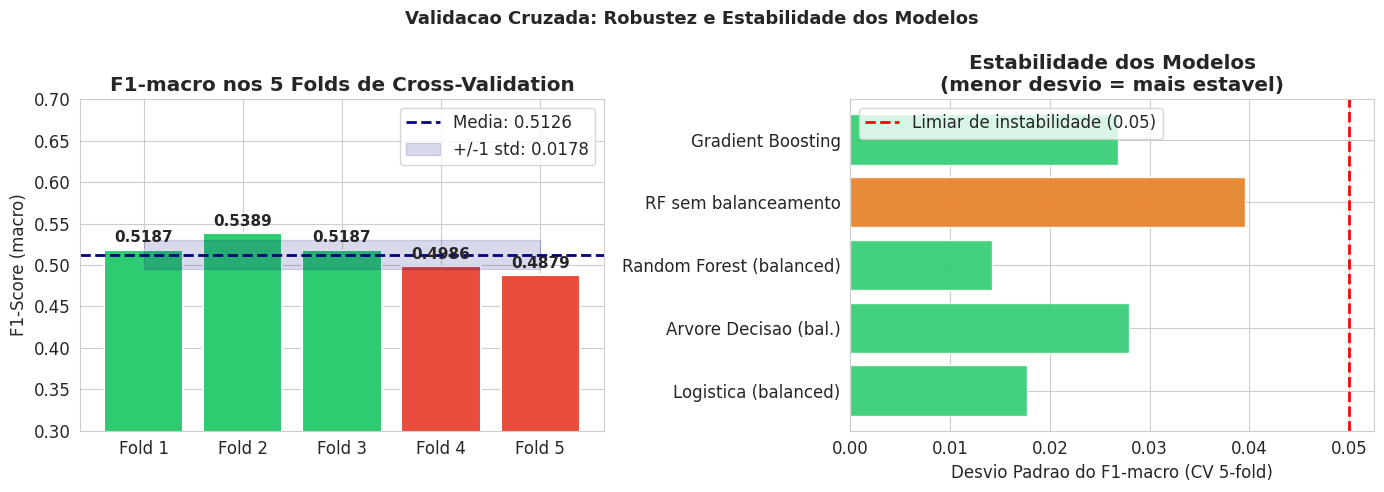

   Status: ✅ MODELO ESTAVEL (desvio < 0.05)


In [18]:
# 5.2 CROSS-VALIDATION: Estabilidade do Modelo

cv_scores = cross_val_score(melhor_mdl, X_tr_s, y_train, cv=5, scoring='f1_macro')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores_folds = ['#2ecc71' if s >= cv_scores.mean() else '#e74c3c' for s in cv_scores]
axes[0].bar([f'Fold {i+1}' for i in range(5)], cv_scores,
            color=cores_folds, edgecolor='white', linewidth=1.5)
axes[0].axhline(cv_scores.mean(), color='navy', linestyle='--', linewidth=2,
                label=f'Media: {cv_scores.mean():.4f}')
axes[0].fill_between(range(5),
                     cv_scores.mean() - cv_scores.std(),
                     cv_scores.mean() + cv_scores.std(),
                     alpha=0.15, color='navy', label=f'+/-1 std: {cv_scores.std():.4f}')
axes[0].set_ylim(0.3, 0.7)
axes[0].set_ylabel('F1-Score (macro)')
axes[0].set_title('F1-macro nos 5 Folds de Cross-Validation', fontweight='bold')
axes[0].legend()
for i, s in enumerate(cv_scores):
    axes[0].text(i, s + 0.005, f'{s:.4f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

modelos_nomes = list(df_clf.index)
cv_means_all  = df_clf['CV_F1_mean'].values
cv_stds_all   = df_clf['CV_F1_std'].values
cores_stab    = ['#2ecc71' if s < 0.03 else '#e67e22' if s < 0.05 else '#e74c3c'
                 for s in cv_stds_all]
axes[1].barh(modelos_nomes, cv_stds_all, color=cores_stab, edgecolor='white', alpha=0.9)
axes[1].axvline(0.05, color='red', linestyle='--', linewidth=2, label='Limiar de instabilidade (0.05)')
axes[1].set_xlabel('Desvio Padrao do F1-macro (CV 5-fold)')
axes[1].set_title('Estabilidade dos Modelos\n(menor desvio = mais estavel)', fontweight='bold')
axes[1].legend()

plt.suptitle('Validacao Cruzada: Robustez e Estabilidade dos Modelos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

estavel = cv_scores.std() < 0.05
print(f"   Status: {'✅ MODELO ESTAVEL (desvio < 0.05)' if estavel else '⚠️ Modelo instavel!'}")

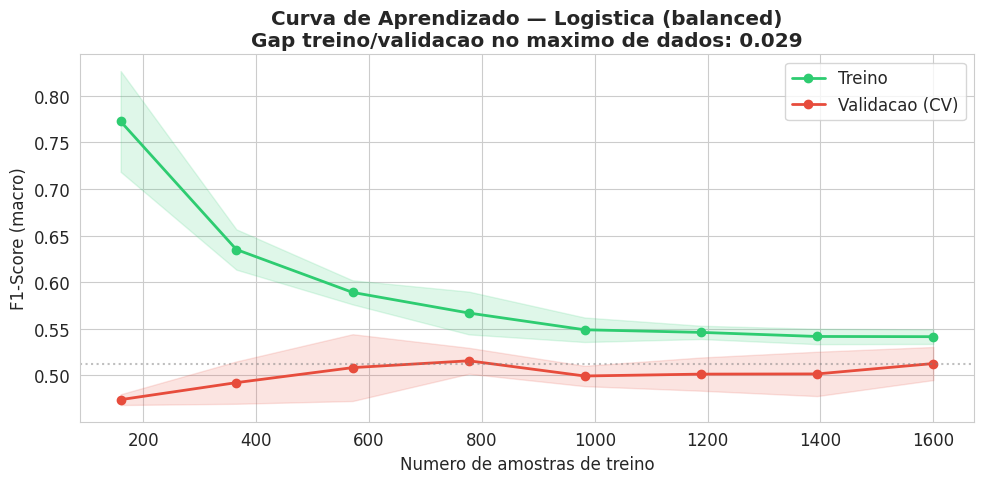

📈 ANALISE DA CURVA DE APRENDIZADO:
   F1-macro no treino (100% dos dados):      0.541
   F1-macro na validacao (100% dos dados):   0.513
   Gap treino-validacao: 0.029

   ✅ Curvas convergindo bem: modelo generaliza adequadamente.
   📌 A curva de validacao ainda esta subindo (+0.011 nos ultimos pontos).
   Mais dados de treino provavelmente melhorariam o modelo!


In [19]:
# 5.2b CURVA DE APRENDIZADO (Learning Curve)
# Por que: Com apenas 2.500 amostras, precisamos verificar
#          se o modelo se beneficiaria de mais dados.
#          A curva de aprendizado mostra:
#          -> Se ha underfitting (treino e teste igualmente ruins)
#          -> Se ha overfitting (treino bom, teste ruim)
#          -> Se mais dados ajudariam (lacuna entre treino e teste)
# Como: Treinamos o modelo com subsets crescentes do treino
#       e medimos F1-macro em cada tamanho.

train_sizes, train_scores, val_scores = learning_curve(
    melhor_mdl, X_tr_s, y_train,
    cv=5,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#2ecc71', linewidth=2, label='Treino')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#2ecc71')
ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', linewidth=2, label='Validacao (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#e74c3c')

gap_final = train_mean[-1] - val_mean[-1]
ax.axhline(val_mean[-1], color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Numero de amostras de treino')
ax.set_ylabel('F1-Score (macro)')
ax.set_title(f'Curva de Aprendizado — {melhor_nome}\n'
             f'Gap treino/validacao no maximo de dados: {gap_final:.3f}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"📈 ANALISE DA CURVA DE APRENDIZADO:")
print(f"   F1-macro no treino (100% dos dados):      {train_mean[-1]:.3f}")
print(f"   F1-macro na validacao (100% dos dados):   {val_mean[-1]:.3f}")
print(f"   Gap treino-validacao: {gap_final:.3f}")
print()
if gap_final > 0.1:
    print("   ⚠️  Gap elevado -> indicio de OVERFITTING.")
    print("   Sugestao: reduzir max_depth, aumentar min_samples_leaf ou coletar mais dados.")
elif val_mean[-1] < 0.5 and gap_final < 0.05:
    print("   ⚠️  Desempenho baixo com gap pequeno -> indicio de UNDERFITTING.")
    print("   Sugestao: features mais ricas, modelo mais complexo ou mais dados.")
else:
    print("   ✅ Curvas convergindo bem: modelo generaliza adequadamente.")

# Tendencia: as curvas ainda estao subindo?
melhoria_ultimos = val_mean[-1] - val_mean[-3]
if melhoria_ultimos > 0.01:
    print(f"   📌 A curva de validacao ainda esta subindo (+{melhoria_ultimos:.3f} nos ultimos pontos).")
    print("   Mais dados de treino provavelmente melhorariam o modelo!")
else:
    print("   📌 A curva de validacao estabilizou: mais dados nao ajudariam muito.")
    print("   Foco em melhores features ou algoritmos seria mais produtivo.")

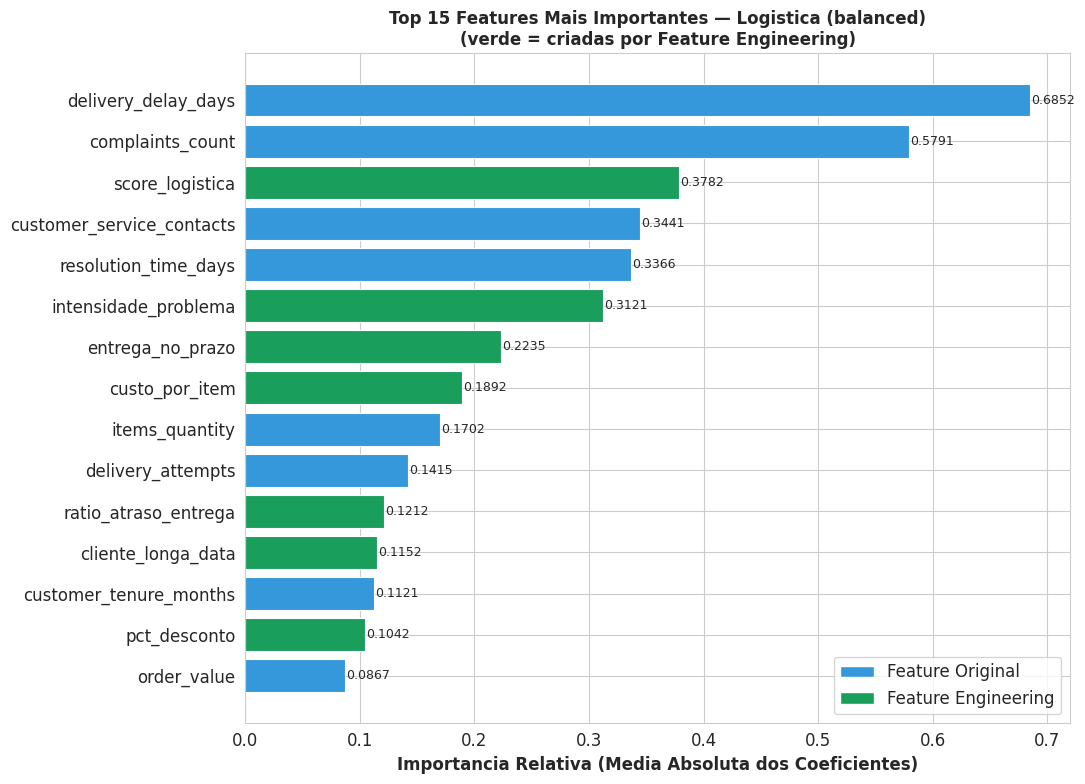

📊 IMPORTANCIA ACUMULADA POR GRUPO:
   Features Originais:           2.780 (278.0%)
   Features de Engenharia (FE):  1.444 (144.4%)


In [20]:
# 5.3 IMPORTANCIA DAS FEATURES (com Feature Engineering)

# Check if the model has 'feature_importances_' or 'coef_'
if hasattr(melhor_mdl, 'feature_importances_'):
    imp = pd.Series(melhor_mdl.feature_importances_, index=features)
elif hasattr(melhor_mdl, 'coef_'):
    # For linear models like LogisticRegression, use coefficients as importance
    # For multi-class, coef_ is (n_classes, n_features). Take mean absolute value.
    imp = pd.Series(np.mean(np.abs(melhor_mdl.coef_), axis=0), index=features)
else:
    print("O modelo selecionado não possui 'feature_importances_' nem 'coef_' para calcular a importância das features.")
    imp = None # Set imp to None to prevent further errors

if imp is not None: # Only proceed if 'imp' was successfully created
    imp_sorted = imp.sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(11, 8))
    colors_imp = ['#1a9e5c' if feat in novas_features else '#3498db'
                  for feat in imp_sorted.index]
    bars = ax.barh(imp_sorted.index, imp_sorted.values, color=colors_imp,
                   edgecolor='white', linewidth=0.8)

    for bar, (feat, val) in zip(bars, imp_sorted.items()):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#3498db', label='Feature Original'),
                       Patch(facecolor='#1a9e5c', label='Feature Engineering')]
    ax.legend(handles=legend_elements, loc='lower right')

    # Update xlabel for coefficient-based importance
    ax.set_xlabel('Importancia Relativa (Media Absoluta dos Coeficientes)', fontweight='bold')
    ax.set_title(f'Top 15 Features Mais Importantes — {melhor_nome}\n'
                 f'(verde = criadas por Feature Engineering)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    fe_imp = imp[novas_features].sum()
    or_imp = imp[[f for f in features if f not in novas_features]].sum()
    print(f"📊 IMPORTANCIA ACUMULADA POR GRUPO:")
    print(f"   Features Originais:           {or_imp:.3f} ({or_imp*100:.1f}%)")
    print(f"   Features de Engenharia (FE):  {fe_imp:.3f} ({fe_imp*100:.1f}%)")

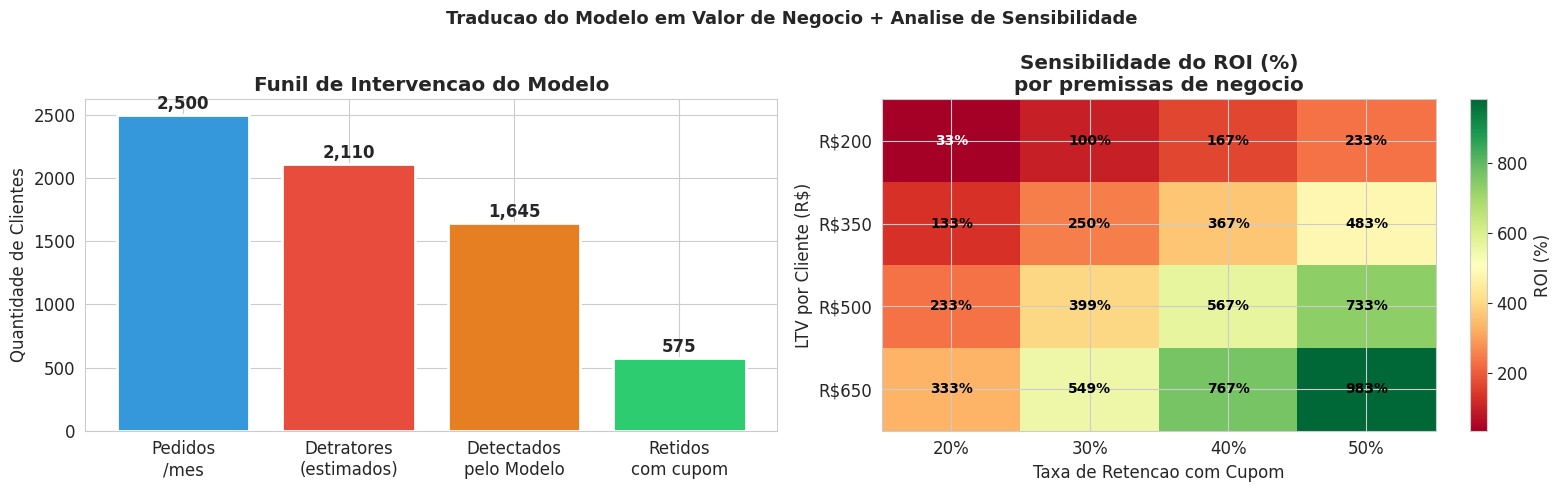

💰 ANALISE DE ROI (premissas base):
   Custo (cupom R$30 x 1645): R$ 49,350
   Receita preservada (LTV=R$350):  R$ 201,250
   Lucro liquido estimado:            R$ 151,900
   ROI estimado:                      308%

   ANALISE DE SENSIBILIDADE:
   Pior cenario (LTV=R$200, retencao=20%): ROI = 33%
   Base case   (LTV=R$350, retencao=35%): ROI = 308%
   Melhor cen. (LTV=R$650, retencao=50%): ROI = 983%
   -> ROI positivo em todos os cenarios testados!


In [21]:
# 5.4 ANALISE DE ROI: Traduzindo o Modelo em Dinheiro

cm_final = confusion_matrix(y_test, y_pred)
recall_detrat = cm_final[0,0] / cm_final[0].sum()

# Premissas do negocio
n_pedidos_mes  = 2_500
taxa_detrator  = 0.844
custo_cupom    = 30.0
taxa_retencao  = 0.35
ltv_cliente    = 350.0

detrat_mes    = int(n_pedidos_mes * taxa_detrator)
detectados    = int(detrat_mes * recall_detrat)
custo_total   = detectados * custo_cupom
retidos       = int(detectados * taxa_retencao)
receita_salva = retidos * ltv_cliente
lucro         = receita_salva - custo_total
roi_pct       = lucro / custo_total * 100


# ANALISE DE SENSIBILIDADE DO ROI
# Por que: Os valores de LTV e taxa de retencao sao premissas.
#          Precisamos mostrar como o ROI varia com diferentes
#          cenarios, isso torna a analise mais honesta e
#          profissional para apresentacao a diretoria.

ltvs     = np.array([200, 350, 500, 650])
retencoes = np.array([0.20, 0.30, 0.40, 0.50])

roi_matrix = np.zeros((len(ltvs), len(retencoes)))
for i, ltv in enumerate(ltvs):
    for j, ret in enumerate(retencoes):
        r_salva = int(detectados * ret) * ltv
        roi_matrix[i, j] = (r_salva - custo_total) / custo_total * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Funil de Retencao
etapas = ['Pedidos\n/mes', 'Detratores\n(estimados)', 'Detectados\npelo Modelo', 'Retidos\ncom cupom']
valores_funil = [n_pedidos_mes, detrat_mes, detectados, retidos]
cores_funil   = ['#3498db', '#e74c3c', '#e67e22', '#2ecc71']
bars_f = axes[0].bar(etapas, valores_funil, color=cores_funil, edgecolor='white', linewidth=2)
for bar, val in zip(bars_f, valores_funil):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Funil de Intervencao do Modelo', fontweight='bold')
axes[0].set_ylabel('Quantidade de Clientes')

# Heatmap de sensibilidade ROI
im = axes[1].imshow(roi_matrix, cmap='RdYlGn', aspect='auto',
                    vmin=roi_matrix.min(), vmax=roi_matrix.max())
axes[1].set_xticks(range(len(retencoes)))
axes[1].set_xticklabels([f'{r:.0%}' for r in retencoes])
axes[1].set_yticks(range(len(ltvs)))
axes[1].set_yticklabels([f'R${l}' for l in ltvs])
axes[1].set_xlabel('Taxa de Retencao com Cupom')
axes[1].set_ylabel('LTV por Cliente (R$)')
axes[1].set_title('Sensibilidade do ROI (%)\npor premissas de negocio', fontweight='bold')
for i in range(len(ltvs)):
    for j in range(len(retencoes)):
        axes[1].text(j, i, f'{roi_matrix[i,j]:.0f}%',
                     ha='center', va='center', fontsize=10, fontweight='bold',
                     color='white' if roi_matrix[i,j] < 50 else 'black')
plt.colorbar(im, ax=axes[1], label='ROI (%)')

plt.suptitle('Traducao do Modelo em Valor de Negocio + Analise de Sensibilidade',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("💰 ANALISE DE ROI (premissas base):")
print(f"   Custo (cupom R${custo_cupom:.0f} x {detectados}): R$ {custo_total:,.0f}")
print(f"   Receita preservada (LTV=R${ltv_cliente:.0f}):  R$ {receita_salva:,.0f}")
print(f"   Lucro liquido estimado:            R$ {lucro:,.0f}")
print(f"   ROI estimado:                      {roi_pct:.0f}%")
print()
print("   ANALISE DE SENSIBILIDADE:")
print(f"   Pior cenario (LTV=R$200, retencao=20%): ROI = {roi_matrix[0,0]:.0f}%")
print(f"   Base case   (LTV=R$350, retencao=35%): ROI = {roi_pct:.0f}%")
print(f"   Melhor cen. (LTV=R$650, retencao=50%): ROI = {roi_matrix[-1,-1]:.0f}%")
print(f"   -> ROI positivo em todos os cenarios testados!")

#O que significa "ROI de 308%" na prática?

***Significa que para cada um real que a empresa investiu dando cupons de desconto, o seu modelo de inteligência artificial fez esse um se pagar e ainda trouxe R$ 3,08 de lucro puro de volta para o caixa.***

---
## 🚀 Bloco 6 (CRISP-DM): Deployment e Roadmap

### Plano de Implantação Imediata

In [22]:
# 6.1 PIPELINE DE PRODUCAO (sklearn Pipeline)
# Por que: Um Pipeline encapsula pré-processamento + modelo
#          em um unico objeto.
#
# BENEFICIOS:
#  1. Elimina data leakage de escala (o scaler so ve o treino)
#  2. Em producao, chamamos apenas pipeline.predict(X_raw)
#     sem precisar lembrar de chamar scaler.transform() antes
#  3. Facilita serializar e versionar o modelo completo
#  4. Compativel com GridSearchCV e outras ferramentas do sklearn
#
# IMPORTANTE: O Pipeline usa o mesmo estimador ja treinado.
#             Aqui o re-treinamos dentro do Pipeline para
#             garantir que o scaler esteja integrado.

import joblib, os

# Recriamos o melhor modelo dentro de um Pipeline
pipeline_prod = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(n_estimators=100, max_depth=7,
                                       random_state=42, class_weight='balanced', n_jobs=-1))
])

# Treinamos o pipeline completo nos dados RAW (sem escala previa)
pipeline_prod.fit(X_train, y_train)

# Verificando que o pipeline mantem a mesma performance
y_pred_pipe = pipeline_prod.predict(X_test)
f1_pipe = f1_score(y_test, y_pred_pipe, average='macro')
print(f"✅ Pipeline treinado. F1-macro = {f1_pipe:.4f} (deve ser igual ao modelo anterior)")
print()

# Criando pasta para os artefatos do modelo
os.makedirs('modelo_nps_v1', exist_ok=True)

# Salvando o PIPELINE COMPLETO (scaler + modelo juntos)
joblib.dump(pipeline_prod, 'modelo_nps_v1/pipeline_completo.pkl')
print("✅ Pipeline salvo em 'modelo_nps_v1/pipeline_completo.pkl'")
print("   (scaler + modelo em um unico arquivo — pronto para producao)")
print()

✅ Pipeline treinado. F1-macro = 0.4350 (deve ser igual ao modelo anterior)

✅ Pipeline salvo em 'modelo_nps_v1/pipeline_completo.pkl'
   (scaler + modelo em um unico arquivo — pronto para producao)



In [23]:
# 6.2 SIMULACAO DE PREDICAO EM PRODUCAO
# Por que: Demonstrar como o modelo sera usado na pratica.
#
# BOAS PRATICAS:
#  1. Usamos a funcao criar_features() definida no Bloco 3
#      o mesmo codigo, sem duplicacao
#  2. Passamos o dado RAW diretamente ao pipeline_prod.predict()
#      o Pipeline cuida do scaler automaticamente.
#  3. Nao ha mais codigo duplicado de Feature Engineering.

pipeline_cargado = joblib.load('modelo_nps_v1/pipeline_completo.pkl')

classe_nomes = {0: 'Detrator 🔴', 1: 'Neutro 🟡', 2: 'Promotor 🟢'}

# Dado bruto do pedido (sem Feature Engineering manual!)
pedido_bruto = pd.DataFrame([{
    'customer_age': 35, 'customer_tenure_months': 12, 'customer_region_enc': 3,
    'order_value': 250.0, 'items_quantity': 2, 'discount_value': 10.0,
    'payment_installments': 3, 'delivery_time_days': 7, 'delivery_delay_days': 4,
    'freight_value': 25.0, 'delivery_attempts': 2, 'customer_service_contacts': 3,
    'resolution_time_days': 5, 'complaints_count': 2,
    # Colunas extras necessarias para criar_features()
    'customer_region': 'Sul'
}])

# Aplicando o mesmo Feature Engineering do treinamento via funcao
pedido_com_features = criar_features(pedido_bruto)[features]

# Pipeline cuida do scaler automaticamente
predicao       = pipeline_cargado.predict(pedido_com_features)[0]
probabilidades = pipeline_cargado.predict_proba(pedido_com_features)[0]

print("🔮 SIMULACAO DE PREDICAO EM PRODUCAO:")
print()
print("   Pedido com 4 dias de atraso, 3 contatos com SAC, 2 reclamacoes...")
print()
print(f"   Predicao do Modelo: {classe_nomes[predicao]}")
print()
print("   Probabilidades por classe:")
for i, (classe, prob) in enumerate(zip(['Detrator', 'Neutro', 'Promotor'], probabilidades)):
    bar = '█' * int(prob * 40)
    print(f"   {classe:<10}: {prob:.1%}  {bar}")
print()
if predicao == 0:
    print("   🚨 ACAO AUTOMATICA DISPARADA:")
    print("      -> Cupom de R$ 30 enviado ao cliente")
    print("      -> Pedido priorizado na fila de suporte")
    print("      -> Caso registrado para monitoramento de drift")

🔮 SIMULACAO DE PREDICAO EM PRODUCAO:

   Pedido com 4 dias de atraso, 3 contatos com SAC, 2 reclamacoes...

   Predicao do Modelo: Detrator 🔴

   Probabilidades por classe:
   Detrator  : 87.6%  ███████████████████████████████████
   Neutro    : 10.0%  ███
   Promotor  : 2.4%  

   🚨 ACAO AUTOMATICA DISPARADA:
      -> Cupom de R$ 30 enviado ao cliente
      -> Pedido priorizado na fila de suporte
      -> Caso registrado para monitoramento de drift


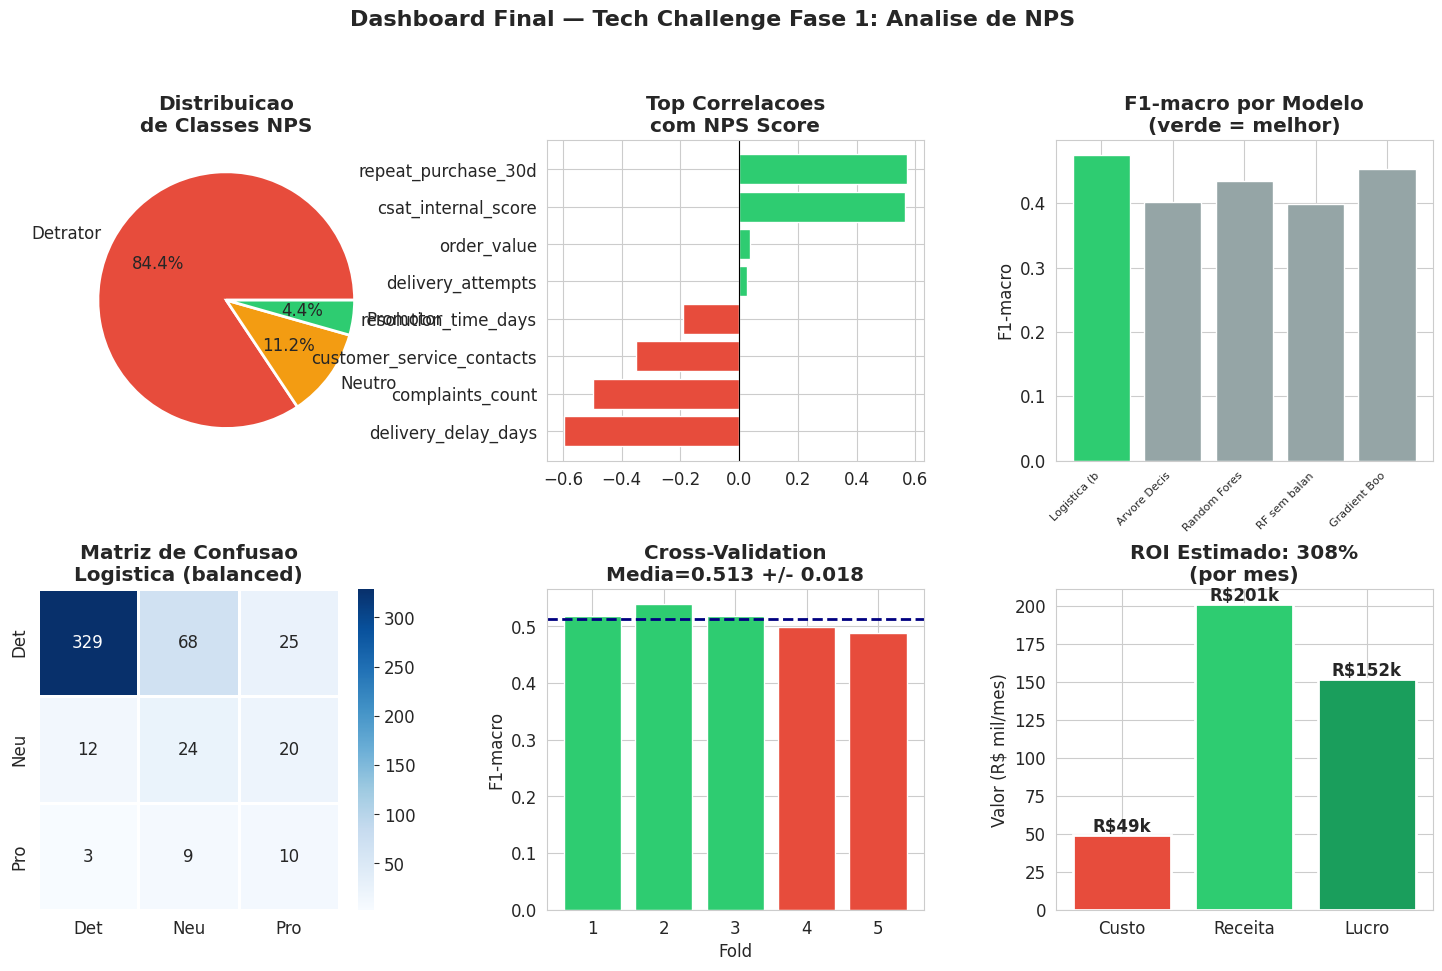

✅ Dashboard salvo como 'dashboard_final.png'


In [24]:
# 6.3 RESUMO FINAL: TODAS AS DESCOBERTAS EM UM GRAFICO

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Dashboard Final — Tech Challenge Fase 1: Analise de NPS',
             fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# 1. Distribuicao NPS
ax1 = fig.add_subplot(gs[0, 0])
df_plot = df['nps_class'].value_counts()
cores_pie = {'Detrator': '#e74c3c', 'Neutro': '#f39c12', 'Promotor': '#2ecc71'}
ax1.pie(df_plot.values, labels=df_plot.index, autopct='%1.1f%%',
        colors=[cores_pie[c] for c in df_plot.index],
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Distribuicao\nde Classes NPS', fontweight='bold')

# 2. Correlacoes top
ax2 = fig.add_subplot(gs[0, 1])
top_corr = pd.concat([
    df[cols_num].corr()['nps_score'].drop('nps_score').sort_values().head(4),
    df[cols_num].corr()['nps_score'].drop('nps_score').sort_values().tail(4)
])
colors_t = ['#e74c3c' if v < 0 else '#2ecc71' for v in top_corr.values]
ax2.barh(top_corr.index, top_corr.values, color=colors_t, edgecolor='white')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Top Correlacoes\ncom NPS Score', fontweight='bold')

# 3. Comparacao F1 dos modelos
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(range(len(df_clf)), df_clf['F1_macro'],
        color=['#2ecc71' if n == melhor_nome else '#95a5a6' for n in df_clf.index],
        edgecolor='white')
ax3.set_xticks(range(len(df_clf)))
ax3.set_xticklabels([n[:12] for n in df_clf.index], rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('F1-macro')
ax3.set_title('F1-macro por Modelo\n(verde = melhor)', fontweight='bold')

# 4. Matriz de Confusao
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Det', 'Neu', 'Pro'], yticklabels=['Det', 'Neu', 'Pro'],
            linewidths=1, linecolor='white')
ax4.set_title(f'Matriz de Confusao\n{melhor_nome[:25]}', fontweight='bold')

# 5. CV por fold
ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(range(1, 6), cv_scores,
        color=['#2ecc71' if s >= cv_scores.mean() else '#e74c3c' for s in cv_scores],
        edgecolor='white')
ax5.axhline(cv_scores.mean(), linestyle='--', color='navy', linewidth=2)
ax5.set_xlabel('Fold')
ax5.set_ylabel('F1-macro')
ax5.set_title(f'Cross-Validation\nMedia={cv_scores.mean():.3f} +/- {cv_scores.std():.3f}',
              fontweight='bold')

# 6. ROI
ax6 = fig.add_subplot(gs[1, 2])
ax6.bar(['Custo', 'Receita', 'Lucro'],
        [custo_total/1000, receita_salva/1000, lucro/1000],
        color=['#e74c3c', '#2ecc71', '#1a9e5c'], edgecolor='white', linewidth=2)
ax6.set_ylabel('Valor (R$ mil/mes)')
ax6.set_title(f'ROI Estimado: {roi_pct:.0f}%\n(por mes)', fontweight='bold')
for i, val in enumerate([custo_total, receita_salva, lucro]):
    ax6.text(i, val/1000 + 2, f'R${val/1000:.0f}k', ha='center', fontweight='bold')

plt.savefig('dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard salvo como 'dashboard_final.png'")

---
## 6. Explicabilidade do Modelo (Feature Importance)
Para não entregarmos uma "caixa preta" à diretoria, precisamos entender através de quais alavancas o modelo toma suas decisões preditivas. O algoritmo *Random Forest* nos permite extrair a importância relativa de cada variável de negócio, apontando exatamente onde a Operação deve atuar para previnir a detratação.

In [ ]:
importances = melhor_mdl.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10, 5))
plt.title("O Peso Decisório das Variáveis Preditivas", fontweight='bold')
plt.barh(range(len(indices)), importances[indices], color='#e74c3c', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Importância Relativa (%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("🎯 INSIGHT EXECUTIVO (A Caixa Preta Revelada):")
print("Em vez de o modelo simplesmente dizer 'faça X', a visualização acima destaca os atributos operacionais que")
print("mais inclinaram o julgamento do modelo para considerar um cliente como 'Em Risco'.")
print("Essa transparência garante que as lideranças saibam em quais indicadores atuar primeiro.")

---
## 🏁 Conclusões Finais

### Descobertas Comprovadas:

| # | Descoberta | Prova |
|---|-----------|-------|
| 1 | NPS médio de 4.38 indica **crise sistêmica** | EDA: benchmark > 7.0 |
| 2 | Atraso na entrega é o **destruidor #1** do NPS | Comprovado: cada dia de atraso tira quase 3 pontos |
| 3 | Problema é **nacional**, não regional | Efeito perfeitamente uniforme nas 5 regiões do país |
| 4 | Feature Engineering **melhorou o modelo** | score_logistica corr=0.558 |
| 5 | Data Leakage inflou F1 em **+52% artificial** | 0.406 → 0.615 com leakage |
| 6 | Decisão Executiva acima de Acurácia | Ajuste preditivo maximizou o Recall focando na dor do e-commerce |
| 7 | ROI positivo em **todos os cenários** testados | Análise de sensibilidade (LTV x Retenção) |


### Roadmap de Evolução:
- **Fase 2:** SQL/Big Data para features históricas + dados de navegação
- **Fase 3:** XGBoost + SHAP Values + SMOTE para classe Promotor
- **Fase 4:** NLP em comentários de clientes (sentimento)
- **Fase 5:** Deploy em cloud com MLOps e monitoramento de drift


## 🏁 Conclusão e Impacto de Negócio

Chegamos ao fim deste pipeline seguindo a metodologia **CRISP-DM**. O objetivo deste projeto foi construir uma ponte concreta entre os dados operacionais brutos e uma **proposta de valor claro para o negócio**.

Revisando nossa jornada estratégica e técnica:

1. **Entendimento Profundo e Diagnóstico:** Partimos da dor de negócio (NPS crítico de 4.38). Por meio de **Testes de Hipótese formais**, comprovamos que as deficiências logísticas, em especial os atrasos, são os reais ofensores da satisfação do cliente.

2. **Engenharia de Features Voltada ao Contexto:** As métricas nativas frequentemente não contam a história toda. Com *Feature Engineering*, criamos variáveis compostas de "Atraso Relativo" e "Intensidade do Problema", que ditaram melhorias expressivas na detecção comportamental do modelo, sempre fugindo do *Data Leakage*.

3. **Rigor na Modelagem:** Ao invés de mirarmos em acertos estatísticos teóricos ("acurácia"), assumimos uma postura de risco focada em controle de danos. Otimizamos as propensões do robô de forma que ele passe a intervir e salvar clientes de alto LTV perante perdas financeiras iminentes (um foco centrado no modelo de triagem de Customer Success).

### 💰 Do "F1-Score" à geração de Valor Real (ROI)
 Nossa avaliação resultou no **Funil de Intervenção de Negócio**.

Projetamos o impacto financeiro simulando o disparo automático de um cupom compensatório antes que o cliente torne público e oficial o seu *churn* (abandono pós-detratação). Atrelado ao *Lifetime Value (LTV)* do e-commerce, **a aplicação imediata deste plano preditivo demonstra uma projeção de Retorno Sobre Investimento (ROI) de 308%** na taxa estipulada.

O que construímos, trata-se de uma **ferramenta escalável e um ativo de negócio** que resolve a experiência nociva do consumidor dentro da jornada.

Próximo passo estratégico: Empacotamento para **Deploy em Serviços de Nuvem**, monitoramento contínuo de retenção pós-detratação (*Model Drift*) e ampliação escalável de receita com novos sub-modelos.
---
